In [10]:
#loading filtered rna and atac data
import anndata
from anndata import AnnData
import pandas as pd
import numpy as np

pb_atac_ct = anndata.read_h5ad("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Pseudobulks/ATAC/celltypes/agg_atac_ct.h5ad")
pb_rna_ct = anndata.read_h5ad("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Pseudobulks/RNA/celltypes/agg_rna_ct.h5ad")    

window_sizes = ["10kb", "20kb", "30kb", "40kb", "50kb", "60kb", "70kb", "80kb", "90kb", "100kb"]
base_path = "/home/fgsasse_lrs_1/Downloads/BA/BA_data/TSS windows/20 windows"

gene_peaks_neg = {}
for window in window_sizes:
    gene_peaks_neg[window] = pd.read_csv(f"{base_path}/gene_peak_assignments_{window}_neg.csv")

gene_peaks_pos = {}
for window in window_sizes:
    gene_peaks_pos[window] = pd.read_csv(f"{base_path}/gene_peak_assignments_{window}_pos.csv")

In [11]:
#taking the minimum non-zero value in the pb_rna_ct matrix to add it to all values before log transformation to avoid taking log of zero
import numpy as np
non_zero_mask = (pb_rna_ct.X > 0)
epsilon_rna = np.min(pb_rna_ct.X[non_zero_mask])

#taking the minimum non-zero value in the pb_atac_ct matrix to add it to all values before log transformation to avoid taking log of zero
non_zero_mask = (pb_atac_ct.X > 0)
epsilon_at= np.min(pb_atac_ct.X[non_zero_mask])

In [12]:
#log transformation (for norm. distribution) & scaling 10000000+1
#log scaling both datasets by multiplying by 10 million and adding 1 to avoid log(0) issues, then taking log10
pb_rna_ct.X = np.log10((pb_rna_ct.X+ epsilon_rna)*10000000)
pb_atac_ct.X = np.log10((pb_atac_ct.X+ epsilon_at)*10000000)
print(pb_atac_ct.X)
print(pb_rna_ct.X)

[[0.47813081 0.60905835 1.1497103  ... 0.66218893 4.36622263 4.31868829]
 [0.48389928 0.74628399 1.21274242 ... 0.83503446 4.38017334 4.32866486]
 [0.5285298  0.76616115 1.12997289 ... 1.04254246 4.45317257 4.38114064]
 ...
 [0.52669001 0.91290247 1.25475317 ... 0.85091576 4.41979294 4.35555461]
 [0.50746779 0.73714187 1.21940277 ... 0.93343652 4.39996208 4.33998444]
 [0.2999134  0.71648817 1.13113958 ... 0.80437283 4.38610568 4.33701041]]
[[ 1.21546281  0.90755495  1.00722919 ...  4.62908312  0.66345334
   0.40177832]
 [ 0.84627754  0.71083289  0.84627754 ...  4.62852919  0.84627754
   0.78381414]
 [ 0.90984342  0.90984342  1.32096239 ...  4.64110303  0.86160087
   0.74527688]
 ...
 [ 1.09200045  0.84884222  1.13621962 ...  4.60301187  0.64455393
   0.48945953]
 [ 1.11120246  1.00623551  1.15548828 ...  4.63366005  0.26098041
   0.66251357]
 [ 0.87397741  0.87397741  0.87397741 ...  4.62743834 -0.35950522
  -0.35950522]]


In [13]:
#make sure the two datasets have the index samples in the same order
pb_atac_ct = pb_atac_ct[pb_rna_ct.obs_names]
print(pb_atac_ct.obs_names)
print(pb_rna_ct.obs_names)

Index(['epidermis', 'pronephros', 'hindbrain', 'spinal_cord', 'neural_optic2',
       'neural_floor_plate', 'neural_crest2', 'PSM', 'optic_cup',
       'lateral_plate_mesoderm', 'midbrain_hindbrain_boundary2',
       'neural_telencephalon', 'differentiating_neurons', 'muscle',
       'fast_muscle', 'heart_myocardium', 'somites', 'NMPs', 'epidermis2',
       'pharyngeal_arches', 'floor_plate2', 'hemangioblasts',
       'neural_posterior', 'floor_plate', 'tail_bud', 'endoderm',
       'midbrain_hindbrain_boundary', 'neural_crest', 'neural_optic',
       'hematopoietic_vasculature', 'endocrine_pancreas', 'hatching_gland',
       'neurons', 'notochord', 'pronephros2', 'enteric_neurons', 'epidermis3',
       'epidermis4', 'neural'],
      dtype='object', name='annotation_ML')
Index(['epidermis', 'pronephros', 'hindbrain', 'spinal_cord', 'neural_optic2',
       'neural_floor_plate', 'neural_crest2', 'PSM', 'optic_cup',
       'lateral_plate_mesoderm', 'midbrain_hindbrain_boundary2',
       '

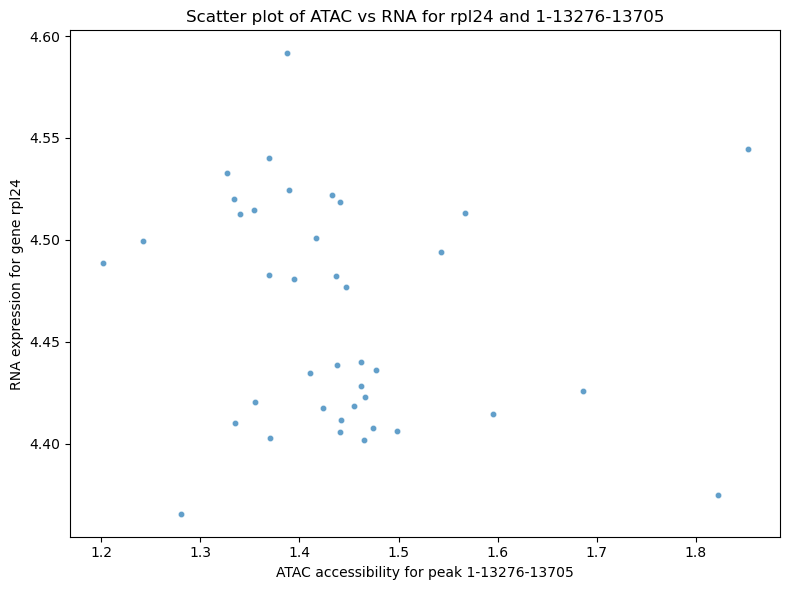

In [18]:
# Scatterplot of RNA and ATAC values for a single gene-peak pair to check correlation
import ast
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select all genes and their assigned peaks from the 10kb gene-peak assignment file
gene_peak_pairs_10kb = gene_peaks_pos["10kb"][["gene_id", "assigned_peaks"]].dropna()

# Select the first gene-peak entry for plotting
first_pair = gene_peak_pairs_10kb.iloc[0]
gene_name = first_pair["gene_id"]
assigned_peaks_raw = first_pair["assigned_peaks"]

if isinstance(assigned_peaks_raw, str):
    assigned_peaks = ast.literal_eval(assigned_peaks_raw)
else:
    assigned_peaks = list(assigned_peaks_raw)

peak_id = assigned_peaks[0]

# Find the index of the gene and peak in the respective datasets
gene_index = pb_rna_ct.var_names.get_loc(gene_name)
peak_index = pb_atac_ct.var_names.get_loc(peak_id)

# Extract the values for the selected gene and peak across all samples
rna_slice = pb_rna_ct.X[:, gene_index]
atac_slice = pb_atac_ct.X[:, peak_index]

rna_values = rna_slice.toarray().ravel() if hasattr(rna_slice, "toarray") else np.asarray(rna_slice).ravel()
atac_values = atac_slice.toarray().ravel() if hasattr(atac_slice, "toarray") else np.asarray(atac_slice).ravel()

# Create a scatter plot to visualize the correlation between the selected gene and peak
plt.figure(figsize=(8, 6))
sns.scatterplot(x=atac_values, y=rna_values, s=20, alpha=0.7)
plt.xlabel(f"ATAC accessibility for peak {peak_id}")
plt.ylabel(f"RNA expression for gene {gene_name}")
plt.title(f"Scatter plot of ATAC vs RNA for {gene_name} and {peak_id}")
plt.tight_layout()
plt.show()

# Computing normal OLS on windows (10kb and 20kb) with n_assigned_peaks < n_samples

In [17]:
#check the maximum number of peaks assigned to each gene in the all windows for both positive and negative windows
for window in window_sizes:
    gene_peaks_pos[window]["num_assigned_peaks"] = gene_peaks_pos[window]["assigned_peaks"].apply(lambda x: len(ast.literal_eval(x)) if pd.notnull(x) else 0)
    gene_peaks_neg[window]["num_assigned_peaks"] = gene_peaks_neg[window]["assigned_peaks"].apply(lambda x: len(ast.literal_eval(x)) if pd.notnull(x) else 0)

for window in window_sizes:
    print(gene_peaks_pos[window][["gene_id", "num_assigned_peaks"]].max())
    print(gene_peaks_neg[window][["gene_id", "num_assigned_peaks"]].max())

#number of samples in the pseudobulk datasets
print(pb_rna_ct.n_obs)
print(pb_atac_ct.n_obs)

gene_id               zzz3
num_assigned_peaks      11
dtype: object
gene_id               zzz3
num_assigned_peaks      10
dtype: object
gene_id               zzz3
num_assigned_peaks      18
dtype: object
gene_id               zzz3
num_assigned_peaks      18
dtype: object
gene_id               zzz3
num_assigned_peaks      24
dtype: object
gene_id               zzz3
num_assigned_peaks      23
dtype: object
gene_id               zzz3
num_assigned_peaks      32
dtype: object
gene_id               zzz3
num_assigned_peaks      31
dtype: object
gene_id               zzz3
num_assigned_peaks      37
dtype: object
gene_id               zzz3
num_assigned_peaks      36
dtype: object
gene_id               zzz3
num_assigned_peaks      44
dtype: object
gene_id               zzz3
num_assigned_peaks      43
dtype: object
gene_id               zzz3
num_assigned_peaks      50
dtype: object
gene_id               zzz3
num_assigned_peaks      49
dtype: object
gene_id               zzz3
num_assigned_peaks   

In [8]:
#computing OLS regression for 10kb window
import numpy as np
import pandas as pd
import ast
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

# ── configure window ──────────────────────────────────────────────────────────
window_label  = "10kb"
gene_peaks_df = gene_peaks_10kb

# ── result store ──────────────────────────────────────────────────────────────
ols_results = {}
gene_peaks_indexed = gene_peaks_df.set_index("gene_id")

# ── OLS loop per gene ─────────────────────────────────────────────────────────
for gene_id in gene_peaks_indexed.index:
    assigned_peaks_raw = gene_peaks_indexed.loc[gene_id, "assigned_peaks"]

    if isinstance(assigned_peaks_raw, str):
        assigned_peaks = ast.literal_eval(assigned_peaks_raw) 
    else:
        assigned_peaks = list(assigned_peaks_raw)

    assigned_peaks = [p for p in assigned_peaks if p in pb_atac_ct.var_names] 

    if len(assigned_peaks) == 0: 
        ols_results[gene_id] = {}
        continue

    y = np.asarray(pb_rna_ct[:, gene_id].X).ravel().astype(float) 

    if np.std(y) == 0 or y.shape[0] < 2:
        ols_results[gene_id] = {}
        continue

    X_raw = np.asarray(pb_atac_ct[:, assigned_peaks].X).astype(float)

    # ── normalize ─────────────────────────────────────────────────────────
    peak_stds = X_raw.std(axis=0)
    
    constant_mask = peak_stds == 0
    if constant_mask.any():
        keep_mask      = ~constant_mask # keep only non-constant peaks
        assigned_peaks = [p for p, keep in zip(assigned_peaks, keep_mask) if keep] # filter out constant peaks from the list of assigned peaks
        X_raw          = X_raw[:, keep_mask] # filter out constant peaks from the design matrix
        peak_stds      = peak_stds[keep_mask] # filter out constant peaks from the std array

        if X_raw.shape[1] == 0: # if all peaks were constant, skip OLS for this gene
            ols_results[gene_id] = {}
            continue

    X_raw = (X_raw - X_raw.mean(axis=0)) / peak_stds 

    # ── fit OLS ───────────────────────────────────────────────────────────
    try:
        result  = OLS(y, add_constant(X_raw, prepend=True)).fit()
        pvalues = result.pvalues[1:] 
        coefs   = result.params[1:] 
    except Exception:
        ols_results[gene_id] = {}
        continue

    ols_results[gene_id] = {
        peak_id: {"coef": float(coefs[i]), "pval": float(pvalues[i])} # store coefficients and p-values for each peak
        for i, peak_id in enumerate(assigned_peaks)
    }

print(f"[{window_label}] OLS complete — {len(ols_results)} genes processed")

# ── build tidy DataFrame ──────────────────────────────────────────────────────
ols_res_10kb_df = pd.DataFrame([
    {
        "window": window_label,
        "gene":   gene_id,
        "peak":   peak_id,
        "coef":   stats["coef"],
        "pval":   stats["pval"],
    }
    for gene_id, peak_data in ols_results.items()
    if peak_data
    for peak_id, stats in peak_data.items()
])

print(f"\nOLS DataFrame: {ols_res_10kb_df.shape[0]:,} peak–gene pairs")
print(ols_res_10kb_df.head())

[10kb] OLS complete — 19380 genes processed

OLS DataFrame: 173,645 peak–gene pairs
  window   gene           peak      coef      pval
0   10kb  rpl24    1-2372-3057  0.010627  0.210658
1   10kb  rpl24    1-3427-4032 -0.000448  0.956809
2   10kb  rpl24    1-4469-7268 -0.033500  0.031205
3   10kb  rpl24    1-9541-9969 -0.018306  0.098417
4   10kb  rpl24  1-11007-12962  0.020210  0.132102


In [16]:
#save the ols_res_10kb_df DataFrame as a csv file
ols_res_10kb_df.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_res_10kb_df_ct.csv", index=False)

In [10]:
ols_res_10kb_df.head()

,window,gene,peak,coef,pval
0,10kb,rpl24,1-2372-3057,0.010627,0.210658
1,10kb,rpl24,1-3427-4032,-0.000448,0.956809
2,10kb,rpl24,1-4469-7268,-0.033500,0.031205
3,10kb,rpl24,1-9541-9969,-0.018306,0.098417
4,10kb,rpl24,1-11007-12962,0.020210,0.132102


In [11]:
# ── classify every peak–gene pair into one of three categories ────────────────
def classify_pair(row):
    if row["pval"] <= 0.05 and row["coef"] < 0:
        return "sig. negative"
    elif row["pval"] <= 0.05 and row["coef"] > 0:
        return "sig. positive"
    else:
        return "non-significant"

ols_res_10kb_df["category"] = ols_res_10kb_df.apply(classify_pair, axis=1)
print(ols_res_10kb_df.head())

agg_ols_res_10kb_brief_df = (
    ols_res_10kb_df
    .dropna(subset=["coef", "pval", "category"])
    .groupby(["window", "gene", "category"])
    .size()
    .reset_index(name="count")
)

agg_ols_res_10kb_brief_df.head()

  window   gene           peak      coef      pval         category
0   10kb  rpl24    1-2372-3057  0.010627  0.210658  non-significant
1   10kb  rpl24    1-3427-4032 -0.000448  0.956809  non-significant
2   10kb  rpl24    1-4469-7268 -0.033500  0.031205    sig. negative
3   10kb  rpl24    1-9541-9969 -0.018306  0.098417  non-significant
4   10kb  rpl24  1-11007-12962  0.020210  0.132102  non-significant


,window,gene,category,count
0,10kb,a1cf,non-significant,10
1,10kb,a1cf,sig. positive,1
2,10kb,a2ml,non-significant,10
3,10kb,a2ml,sig. positive,1
4,10kb,aaas,non-significant,5


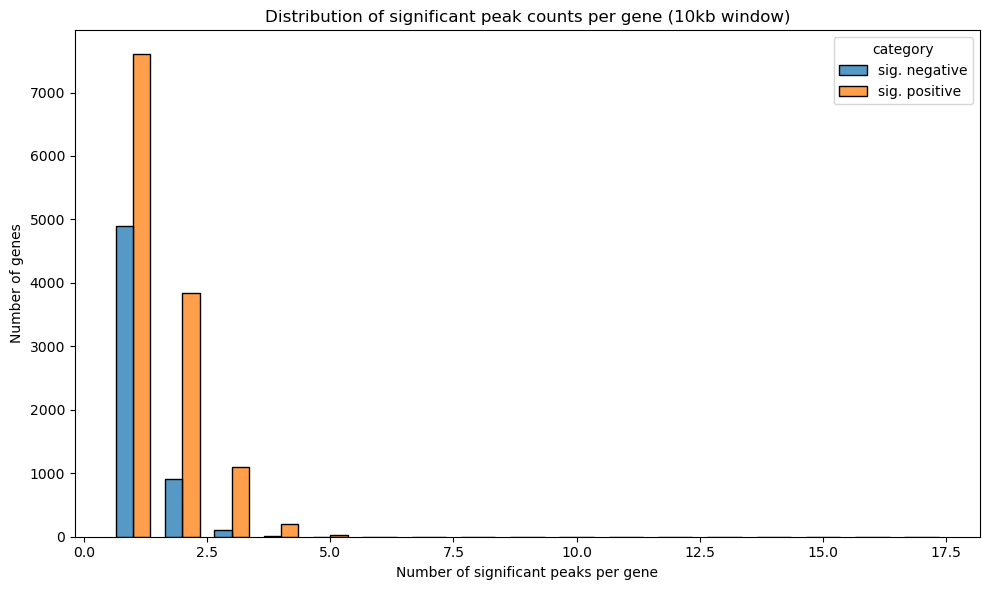

In [12]:
# plot the significant peak counts across all genes for the 10kb window
import matplotlib.pyplot as plt
import seaborn as sns

category_order = ["sig. negative", "sig. positive"]

#histogram of the counts of significant peaks per gene for the 10kb window separately for sig. positive and sig. negative categories
plt.figure(figsize=(10, 6))
sns.histplot(data=agg_ols_res_10kb_brief_df, x="count", hue="category", multiple="dodge", bins=30, hue_order=category_order, discrete=True, shrink=0.7)
plt.xlabel("Number of significant peaks per gene")
plt.ylabel("Number of genes")
plt.title("Distribution of significant peak counts per gene (10kb window)")
plt.tight_layout()
plt.show()

In [7]:
#computing OLS regression for 20kb window by loading the function from the src folder

from pathlib import Path
import sys

src_path = Path("/home/fgsasse_lrs_1/Downloads/BA/src/")

if str(src_path) not in sys.path:
       sys.path.insert(0, str(src_path)),

#import several functions from the src folder to classify peak-gene pairs and aggregate results
from your_package.ols import (
    compute_peak_gene_ols,
    classify_peak_gene_pairs,
    aggregate_peak_gene_categories)


ols_results_20kb, ols_res_20kb_df = compute_peak_gene_ols( 
    rna_data= pb_rna_ct,
    atac_data= pb_atac_ct,
    gene_peaks_df= gene_peaks_20kb,
    window_label= "20kb",
)

ols_res_20kb_df = classify_peak_gene_pairs(ols_res_20kb_df)

agg_ols_res_20kb_brief_df = aggregate_peak_gene_categories(
    ols_res_20kb_df
)

agg_ols_res_20kb_brief_df.head()

[20kb] OLS complete — 19380 genes processed
OLS DataFrame: 363,753 peak–gene pairs


,window,gene,category,count
0,20kb,a1cf,non-significant,17
1,20kb,a1cf,sig. negative,1
2,20kb,a1cf,sig. positive,2
3,20kb,a2ml,non-significant,20
4,20kb,a2ml,sig. negative,1


In [18]:
#save the ols_res_20kb_df DataFrame as a csv file
ols_res_20kb_df.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_res_20kb_df_ct.csv", index=False)

In [152]:
ols_res_20kb_df.head()

,window,gene,peak,coef,pval,category
0,20kb,rpl24,1-32-526,-0.002326,0.724209,non-significant
1,20kb,rpl24,1-2372-3057,-0.000544,0.957907,non-significant
2,20kb,rpl24,1-3427-4032,0.004486,0.636083,non-significant
3,20kb,rpl24,1-4469-7268,-0.035735,0.040825,sig. negative
4,20kb,rpl24,1-9541-9969,-0.018420,0.151080,non-significant


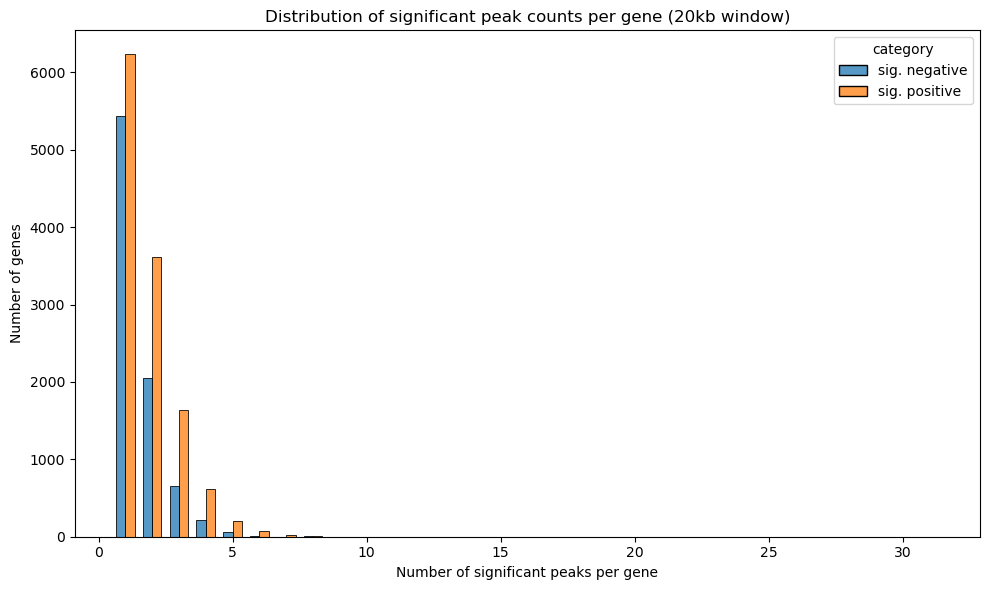

In [21]:
# plot the significant peak counts across all genes for the 20kb window
import matplotlib.pyplot as plt
import seaborn as sns

category_order = ["sig. negative", "sig. positive"]

#histogram of the counts of significant peaks per gene for the 20kb window separately for sig. positive and sig. negative categories
plt.figure(figsize=(10, 6))
sns.histplot(data=agg_ols_res_20kb_brief_df, x="count", hue="category", multiple="dodge", bins=30, hue_order=category_order, discrete=True, shrink=0.7)
plt.xlabel("Number of significant peaks per gene")
plt.ylabel("Number of genes")
plt.title("Distribution of significant peak counts per gene (20kb window)")
plt.tight_layout()
plt.show()

# Bootstrapping OLS for 50kb and 100kb windows

(ols_results_brief)
- saving only frequency of pos./neg. coefficient and average coefficient value of n iterations per peaks per gene

In [15]:
#check the maximum number of peaks assigned to each gene in the 50kb and 100kb windows
gene_peaks_50kb["num_assigned_peaks"] = gene_peaks_50kb["assigned_peaks"].apply(lambda x: len(ast.literal_eval(x)) if pd.notnull(x) else 0)
gene_peaks_100kb["num_assigned_peaks"] = gene_peaks_100kb["assigned_peaks"].apply(lambda x: len(ast.literal_eval(x)) if pd.notnull(x) else 0)
print(gene_peaks_50kb[["gene_id", "num_assigned_peaks"]].max())
print(gene_peaks_100kb[["gene_id", "num_assigned_peaks"]].max())

#number of samples in the pseudobulk datasets
print(pb_rna_ct.n_obs)
print(pb_atac_ct.n_obs)

gene_id               zzz3
num_assigned_peaks      69
dtype: object
gene_id               zzz3
num_assigned_peaks     125
dtype: object
39
39


In [ ]:
# OLS regression of gene expression on peak accessibility per gene (50kb window)
# 1) Bootstrap 100 iterations, sampling min(n_peaks_total, n_samples-2) peaks per iteration and saving only 
# a) the fractions of how many of the sampled peaks are significant 
# b) the average coefficients of the significant peaks across iterations
# (with replacement only when n_peaks_total < n_select, deduplicated to keep OLS valid)

import numpy as np
import pandas as pd
import ast
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

# ── configure window ──────────────────────────────────────────────────────────
window_label  = "50kb"
gene_peaks_df = gene_peaks_50kb

# ── result store ──────────────────────────────────────────────────────────────
ols_results = {}

# ── OLS loop per gene ─────────────────────────────────────────────────────────

# index the dataframe once before the loop
gene_peaks_indexed = gene_peaks_df.set_index("gene_id")

for gene_id in gene_peaks_indexed.index:
    assigned_peaks_raw = gene_peaks_indexed.loc[gene_id, "assigned_peaks"]

    if isinstance(assigned_peaks_raw, str):
        assigned_peaks = ast.literal_eval(assigned_peaks_raw)
    else:
        assigned_peaks = list(assigned_peaks_raw)

    assigned_peaks = [p for p in assigned_peaks if p in pb_atac_ct.var_names]

    if len(assigned_peaks) == 0:
        ols_results[gene_id] = {}
        continue

    y = np.asarray(pb_rna_ct[:, gene_id].X).ravel().astype(float)

    if np.std(y) == 0 or y.shape[0] < 2:
        ols_results[gene_id] = {}
        continue

    X_raw = np.asarray(pb_atac_ct[:, assigned_peaks].X).astype(float)
    n_samples     = X_raw.shape[0]
    n_peaks_total = X_raw.shape[1]

    peak_means = X_raw.mean(axis=0)
    peak_stds  = X_raw.std(axis=0)

    constant_mask = peak_stds == 0
    if constant_mask.any():
        keep_mask      = ~constant_mask
        assigned_peaks = [p for p, keep in zip(assigned_peaks, keep_mask) if keep]
        X_raw          = X_raw[:, keep_mask]
        peak_means     = peak_means[keep_mask]
        peak_stds      = peak_stds[keep_mask]
        n_peaks_total  = X_raw.shape[1]

        if n_peaks_total == 0:
            ols_results[gene_id] = {}
            continue

    X_raw = (X_raw - peak_means) / peak_stds

    n_select = max(1, min(n_peaks_total, n_samples - 2))

    n_iterations           = 1000
    significance_threshold = 0.05

    sig_counts  = np.zeros(n_peaks_total, dtype=float)
    iter_counts = np.zeros(n_peaks_total, dtype=float)
    coef_sums   = np.zeros(n_peaks_total, dtype=float)

    for _ in range(n_iterations):
        replace = n_peaks_total < n_select
        sel_idx = np.random.choice(n_peaks_total, size=n_select, replace=replace)
        sel_idx = np.unique(sel_idx)

        X_sel = add_constant(X_raw[:, sel_idx], prepend=True)

        try:
            result  = OLS(y, X_sel).fit()
            pvalues = result.pvalues[1:]
            coefs   = result.params[1:]
        except Exception:
            continue

        sig_mask = pvalues <= significance_threshold 
        iter_counts[sel_idx] += 1                           
        sig_counts[sel_idx]  += sig_mask.astype(float)
        coef_sums[sel_idx]   += np.where(sig_mask, coefs, 0.0)

    peak_summaries = {} 
    for peak_i, peak_id in enumerate(assigned_peaks): # iterate over all assigned peaks, not just those that were sampled
        if iter_counts[peak_i] == 0: # if a peak was never sampled, we cannot compute stats for it, so we skip it
            continue
    
        n_sig = sig_counts[peak_i]
        peak_summaries[peak_id] = {
            "times_sampled":            int(iter_counts[peak_i]),
            "times_significant":        int(n_sig),
            "significance_rate":        n_sig / iter_counts[peak_i],
            "mean_coef_if_significant": coef_sums[peak_i] / n_sig if n_sig > 0 else np.nan,
        }

    ols_results[gene_id] = {
        "meta": {
            "n_samples":     n_samples,
            "n_peaks_total": n_peaks_total,
            "n_select":      n_select,
            "n_iterations":  n_iterations,
        },
        "peaks": peak_summaries,
    }

print(f"[{window_label}] Bootstrap complete — {len(ols_results)} genes processed")

# ── build tidy DataFrame ──────────────────────────────────────────────────────
all_rows = []

for gene_id, gene_data in ols_results.items():
    if not gene_data or "peaks" not in gene_data:
        continue

    meta = gene_data["meta"]

    for peak_id, stats in gene_data["peaks"].items():
        all_rows.append({
            "window":                   window_label,
            "gene":                     gene_id,
            "peak":                     peak_id,
            "n_samples":                meta["n_samples"],
            "n_peaks_total":            meta["n_peaks_total"],
            "n_select":                 meta["n_select"],
            "n_iterations":             meta["n_iterations"],
            "times_sampled":            stats["times_sampled"],
            "times_significant":        stats["times_significant"],
            "significance_rate":        stats["significance_rate"],
            "mean_coef_if_significant": stats["mean_coef_if_significant"],
        })

ols_res_50kb_brief_df = pd.DataFrame(all_rows)

print(f"\nBootstrap summary DataFrame: {ols_res_50kb_brief_df.shape[0]:,} peak–gene pairs")
print(ols_res_50kb_brief_df.head())

[50kb] Bootstrap complete — 19380 genes processed

Bootstrap summary DataFrame: 19,373 peak–gene pairs
  window     gene           peak  n_samples  n_peaks_total  n_select  \
0   50kb    rpl24  1-58412-61085         39             31        31   
1   50kb    cep97  1-58412-61085         39             31        31   
2   50kb   nfkbiz  1-67609-68064         39             36        36   
3   50kb      eed  1-76043-76855         39             40        37   
4   50kb  hikeshi  1-85649-86704         39             44        37   

   n_iterations  times_sampled  times_significant  significance_rate  \
0          1000           1000                  0           0.000000   
1          1000           1000               1000           1.000000   
2          1000           1000                  0           0.000000   
3          1000            916                 38           0.041485   
4          1000            850                 58           0.068235   

   mean_coef_if_significant  
0

In [8]:
#number of assigned peaks per gene in 50kb window
print("\nNumber of max. assigned peaks:")
assigned_peaks_counts = gene_peaks_50kb["assigned_peaks"].apply(lambda x: len(ast.literal_eval(x)) if pd.notna(x) else 0)
print(assigned_peaks_counts.max())

print("\nNumber of times sampled (min and max):")
print(ols_res_50kb_brief_df['times_sampled'].min())
print(ols_res_50kb_brief_df['times_sampled'].max())
#count the number of significant peaks per gene at a threshold of 0.05
significant_peaks_per_gene = ols_res_50kb_brief_df[ols_res_50kb_brief_df["significance_rate"] >= 0.05].groupby("gene").size()
print("\nNumber of significant peaks per gene at threshold 0.05:")
print(significant_peaks_per_gene.head())

#save the gene names in significant_peaks_per_gene.head() to a list
significant_genes = significant_peaks_per_gene.head().index.tolist()

#number of assigned peaks of theses genes
assigned_peaks_counts = gene_peaks_50kb[gene_peaks_50kb["gene_id"].isin(significant_genes)].set_index("gene_id")["assigned_peaks"].apply(lambda x: len(ast.literal_eval(x)) if pd.notna(x) else 0)
print("\nNumber of assigned peaks for the top significant genes:")
print(assigned_peaks_counts.head())



Number of max. assigned peaks:
69

Number of times sampled (min and max):
539
1000

Number of significant peaks per gene at threshold 0.05:
gene
aaas     1
aadac    1
aamp     1
aar2     1
aars1    1
dtype: int64

Number of assigned peaks for the top significant genes:
gene_id
aamp     46
aaas     51
aadac    52
aars1    46
aar2     48
Name: assigned_peaks, dtype: int64


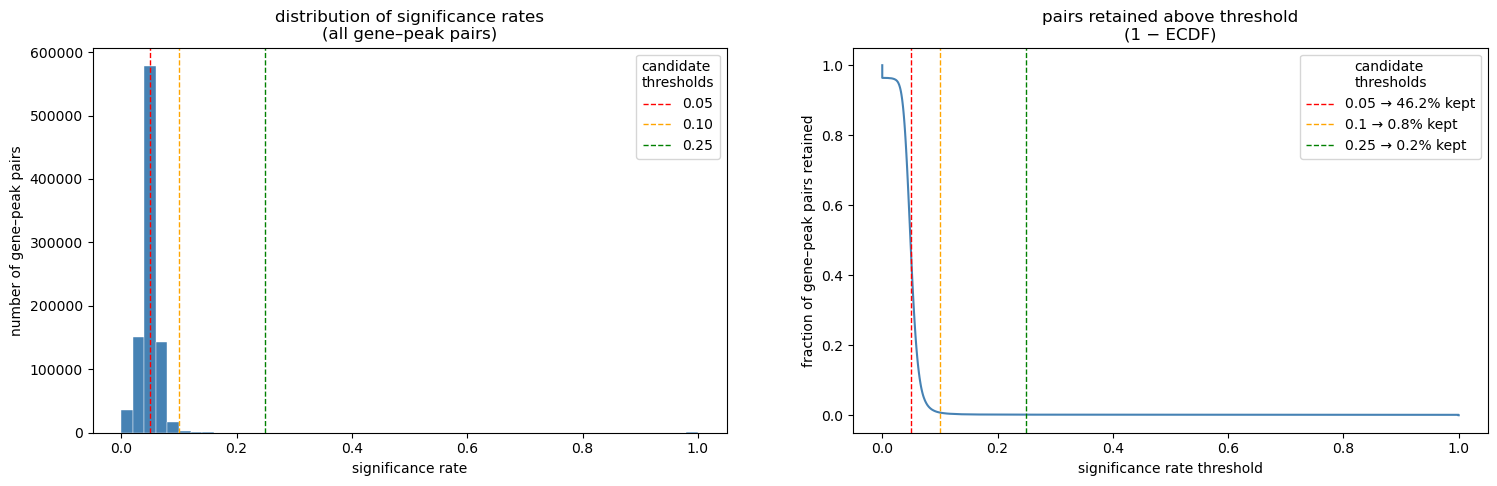

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#plot the significance rates for the 50kb window across all genes and peaks as a histogram and ECDF

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# ── 1. histogram of significance rates across all gene–peak pairs ─────────────
axes[0].hist(
    ols_res_50kb_brief_df["significance_rate"],
    bins=50,
    edgecolor="white",
    linewidth=0.3,
    color="steelblue",
)
axes[0].set_xlabel("significance rate")
axes[0].set_ylabel("number of gene–peak pairs")
axes[0].set_title("distribution of significance rates\n(all gene–peak pairs)")
axes[0].axvline(0.05, color="red",    linestyle="--", linewidth=1, label="0.05")
axes[0].axvline(0.10, color="orange", linestyle="--", linewidth=1, label="0.10")
axes[0].axvline(0.25, color="green",  linestyle="--", linewidth=1, label="0.25")
axes[0].legend(title="candidate\nthresholds")

# ── 2. ECDF — what fraction of pairs survive a given threshold ────────────────
sorted_rates = np.sort(ols_res_50kb_brief_df["significance_rate"])
ecdf_y       = np.arange(1, len(sorted_rates) + 1) / len(sorted_rates)

axes[1].plot(sorted_rates, 1 - ecdf_y, color="steelblue", linewidth=1.5)
axes[1].set_xlabel("significance rate threshold")
axes[1].set_ylabel("fraction of gene–peak pairs retained")
axes[1].set_title("pairs retained above threshold\n(1 − ECDF)")
for thresh, color in [(0.05, "red"), (0.10, "orange"), (0.25, "green")]:
    frac = (ols_res_50kb_brief_df["significance_rate"] >= thresh).mean()
    axes[1].axvline(thresh, color=color, linestyle="--", linewidth=1,
                    label=f"{thresh} → {frac:.1%} kept")
axes[1].legend(title="candidate\nthresholds")


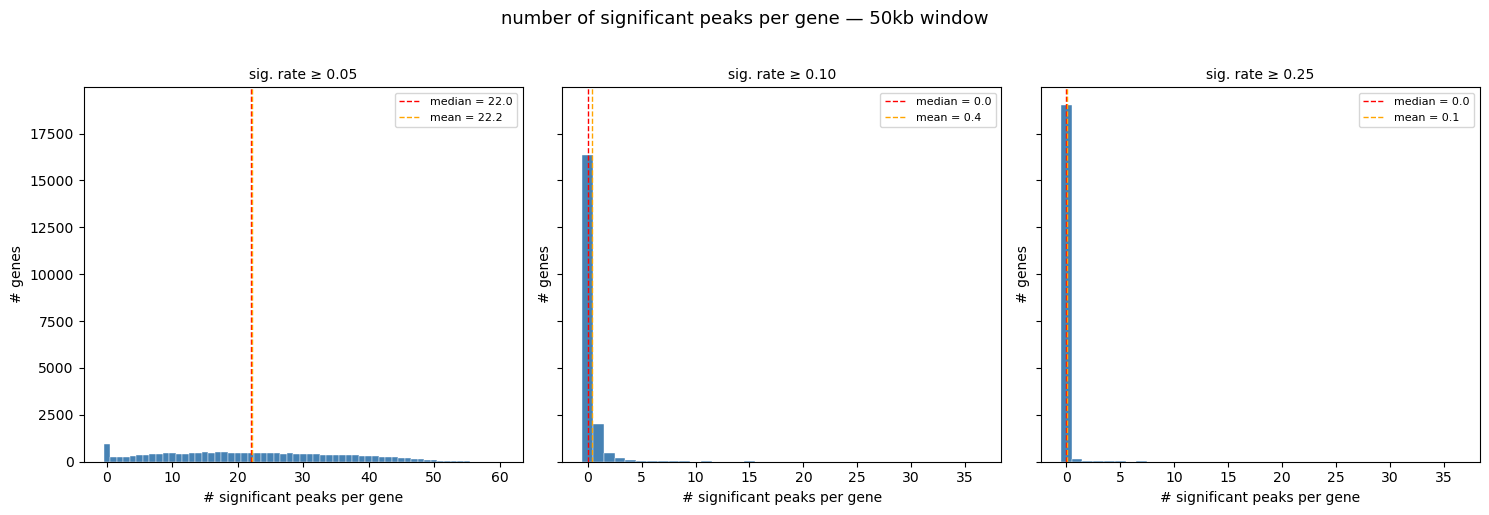

In [14]:
#count significant peaks per gene per window
sig_peaks_per_gene = (
    ols_res_50kb_brief_df
    .groupby(["window", "gene"])
    .agg(
        n_peaks_total        = ("peak", "count"),
        n_significant        = ("significance_rate", lambda x: (x > 0).sum()),
        n_sig_05             = ("significance_rate", lambda x: (x >= 0.05).sum()),
        n_sig_10             = ("significance_rate", lambda x: (x >= 0.10).sum()),
        n_sig_25             = ("significance_rate", lambda x: (x >= 0.25).sum()),
    )
    .reset_index()
)

sig_peaks_per_gene["window"] = pd.Categorical(
    sig_peaks_per_gene["window"],
    categories=["50kb"],
    ordered=True,
)

#plot the number of sig. peaks per gene for 50kb window and thresholds in a grid of histograms
import matplotlib.pyplot as plt

thresholds     = ["n_sig_05", "n_sig_10", "n_sig_25"]
threshold_labs = ["≥ 0.05",   "≥ 0.10",   "≥ 0.25"]
window         = "50kb"

fig, axes = plt.subplots(1, len(thresholds), figsize=(15, 5), sharey=True)

for col_i, (thresh_col, thresh_lab) in enumerate(zip(thresholds, threshold_labs)):
    ax   = axes[col_i]
    data = sig_peaks_per_gene.loc[
        sig_peaks_per_gene["window"] == window, thresh_col
    ]

    ax.hist(
        data,
        bins=range(0, int(data.max()) + 2),
        edgecolor="white",
        linewidth=0.3,
        color="steelblue",
        align="left",
    )

    ax.axvline(data.median(), color="red",    linestyle="--",
               linewidth=1, label=f"median = {data.median():.1f}")
    ax.axvline(data.mean(),   color="orange", linestyle="--",
               linewidth=1, label=f"mean = {data.mean():.1f}")

    ax.set_title(f"sig. rate {thresh_lab}", fontsize=10)
    ax.set_xlabel("# significant peaks per gene")
    ax.set_ylabel("# genes")
    ax.legend(fontsize=8)

plt.suptitle(
    f"number of significant peaks per gene — {window} window",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()

In [ ]:
# OLS regression of gene expression on peak accessibility per gene (100kb window)
# 1) Bootstrap 100 iterations, sampling min(n_peaks_total, n_samples-2) peaks per iteration and saving only 
# a) the fractions of how many of the sampled peaks are significant 
# b) the average coefficients of the significant peaks across iterations
# (with replacement only when n_peaks_total < n_select, deduplicated to keep OLS valid)

import numpy as np
import pandas as pd
import ast
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

# ── configure window ──────────────────────────────────────────────────────────
window_label  = "100kb"
gene_peaks_df = gene_peaks_100kb

# ── result store ──────────────────────────────────────────────────────────────
ols_results = {}

# ── OLS loop per gene ─────────────────────────────────────────────────────────

# index the dataframe once before the loop
gene_peaks_indexed = gene_peaks_df.set_index("gene_id")

for gene_id in gene_peaks_indexed.index:
    assigned_peaks_raw = gene_peaks_indexed.loc[gene_id, "assigned_peaks"]

    if isinstance(assigned_peaks_raw, str):
        assigned_peaks = ast.literal_eval(assigned_peaks_raw)
    else:
        assigned_peaks = list(assigned_peaks_raw)

    assigned_peaks = [p for p in assigned_peaks if p in pb_atac_ct.var_names]

    if len(assigned_peaks) == 0:
        ols_results[gene_id] = {}
        continue

    y = np.asarray(pb_rna_ct[:, gene_id].X).ravel().astype(float)

    if np.std(y) == 0 or y.shape[0] < 2:
        ols_results[gene_id] = {}
        continue

    X_raw = np.asarray(pb_atac_ct[:, assigned_peaks].X).astype(float)
    n_samples     = X_raw.shape[0]
    n_peaks_total = X_raw.shape[1]

    peak_means = X_raw.mean(axis=0)
    peak_stds  = X_raw.std(axis=0)

    constant_mask = peak_stds == 0
    if constant_mask.any():
        keep_mask      = ~constant_mask
        assigned_peaks = [p for p, keep in zip(assigned_peaks, keep_mask) if keep]
        X_raw          = X_raw[:, keep_mask]
        peak_means     = peak_means[keep_mask]
        peak_stds      = peak_stds[keep_mask]
        n_peaks_total  = X_raw.shape[1]

        if n_peaks_total == 0:
            ols_results[gene_id] = {}
            continue

    X_raw = (X_raw - peak_means) / peak_stds

    n_select = max(1, min(n_peaks_total, n_samples - 2))

    n_iterations           = 1000
    significance_threshold = 0.05

    sig_counts  = np.zeros(n_peaks_total, dtype=float)
    iter_counts = np.zeros(n_peaks_total, dtype=float)
    coef_sums   = np.zeros(n_peaks_total, dtype=float)

    for _ in range(n_iterations):
        replace = n_peaks_total < n_select
        sel_idx = np.random.choice(n_peaks_total, size=n_select, replace=replace)
        sel_idx = np.unique(sel_idx)

        X_sel = add_constant(X_raw[:, sel_idx], prepend=True)

        try:
            result  = OLS(y, X_sel).fit()
            pvalues = result.pvalues[1:]
            coefs   = result.params[1:]
        except Exception:
            continue

        sig_mask = pvalues <= significance_threshold
        iter_counts[sel_idx] += 1
        sig_counts[sel_idx]  += sig_mask.astype(float) 
        coef_sums[sel_idx]   += np.where(sig_mask, coefs, 0.0)

    peak_summaries = {}
    for peak_i, peak_id in enumerate(assigned_peaks): 
        if iter_counts[peak_i] == 0: 
            continue

        n_sig = sig_counts[peak_i]
        peak_summaries[peak_id] = {
            "times_sampled":            int(iter_counts[peak_i]),
            "times_significant":        int(n_sig),
            "significance_rate":        n_sig / iter_counts[peak_i],
            "mean_coef_if_significant": coef_sums[peak_i] / n_sig if n_sig > 0 else np.nan,
        }

    ols_results[gene_id] = {
        "meta": {
            "n_samples":     n_samples,
            "n_peaks_total": n_peaks_total,
            "n_select":      n_select,
            "n_iterations":  n_iterations,
        },
        "peaks": peak_summaries,
    }

print(f"[{window_label}] Bootstrap complete — {len(ols_results)} genes processed")

# ── build tidy DataFrame ──────────────────────────────────────────────────────
all_rows = []

for gene_id, gene_data in ols_results.items():
    if not gene_data or "peaks" not in gene_data:
        continue

    meta = gene_data["meta"]

    for peak_id, stats in gene_data["peaks"].items():
        all_rows.append({
            "window":                   window_label,
            "gene":                     gene_id,
            "peak":                     peak_id,
            "n_samples":                meta["n_samples"],
            "n_peaks_total":            meta["n_peaks_total"],
            "n_select":                 meta["n_select"],
            "n_iterations":             meta["n_iterations"],
            "times_sampled":            stats["times_sampled"],
            "times_significant":        stats["times_significant"],
            "significance_rate":        stats["significance_rate"],
            "mean_coef_if_significant": stats["mean_coef_if_significant"],
        })

ols_res_100kb_brief_df = pd.DataFrame(all_rows)

print(f"\nBootstrap summary DataFrame: {ols_res_100kb_brief_df.shape[0]:,} peak–gene pairs")
print(ols_res_100kb_brief_df.head())

[100kb] Bootstrap complete — 19380 genes processed

Bootstrap summary DataFrame: 1,871,887 peak–gene pairs
  window   gene         peak  n_samples  n_peaks_total  n_select  \
0  100kb  rpl24     1-32-526         39             57        37   
1  100kb  rpl24  1-2372-3057         39             57        37   
2  100kb  rpl24  1-3427-4032         39             57        37   
3  100kb  rpl24  1-4469-7268         39             57        37   
4  100kb  rpl24  1-9541-9969         39             57        37   

   n_iterations  times_sampled  times_significant  significance_rate  \
0          1000            653                 30           0.045942   
1          1000            648                 41           0.063272   
2          1000            623                 39           0.062600   
3          1000            648                 43           0.066358   
4          1000            624                 33           0.052885   

   mean_coef_if_significant  
0                 -0.

In [19]:
#number of assigned peaks per gene in 100kb window
print("\nNumber of max. assigned peaks:")
assigned_peaks_counts = gene_peaks_100kb["assigned_peaks"].apply(lambda x: len(ast.literal_eval(x)) if pd.notna(x) else 0)
print(assigned_peaks_counts.max())

print("\nNumber of times sampled (min and max):")
print(ols_res_100kb_brief_df['times_sampled'].min())
print(ols_res_100kb_brief_df['times_sampled'].max())
#count the number of significant peaks per gene at a threshold of 0.05
significant_peaks_per_gene = ols_res_100kb_brief_df[ols_res_100kb_brief_df["significance_rate"] >= 0.05].groupby("gene").size()
print("\nNumber of significant peaks per gene at threshold 0.05:")
print(significant_peaks_per_gene.head())

#save the gene names in significant_peaks_per_gene.head() to a list
significant_genes = significant_peaks_per_gene.head().index.tolist()

#number of assigned peaks of theses genes
assigned_peaks_counts = gene_peaks_100kb[gene_peaks_100kb["gene_id"].isin(significant_genes)].set_index("gene_id")["assigned_peaks"].apply(lambda x: len(ast.literal_eval(x)) if pd.notna(x) else 0)
print("\nNumber of assigned peaks for the top significant genes:")
print(assigned_peaks_counts.head())


Number of max. assigned peaks:
125

Number of times sampled (min and max):
253
1000

Number of significant peaks per gene at threshold 0.05:
gene
a1cf     50
a2ml     48
aaas     87
aacs     27
aadac    43
dtype: int64

Number of assigned peaks for the top significant genes:
gene_id
aacs      88
aaas     110
a1cf      95
aadac    100
a2ml      77
Name: assigned_peaks, dtype: int64


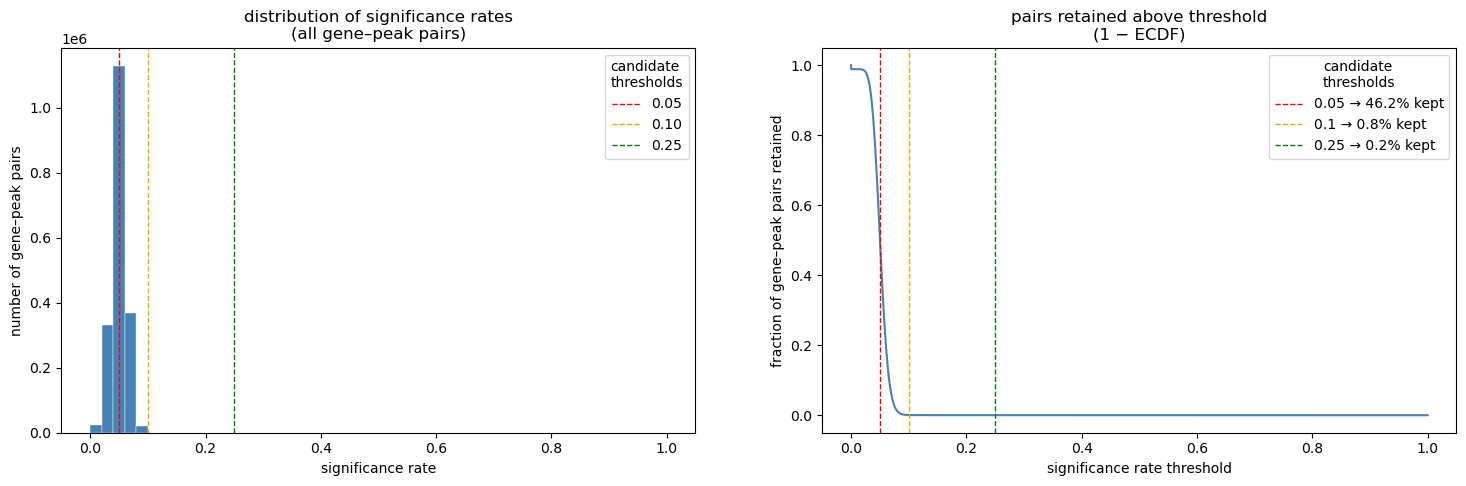

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# ── 1. histogram of significance rates across all gene–peak pairs ─────────────
axes[0].hist(
    ols_res_100kb_brief_df["significance_rate"],
    bins=50,
    edgecolor="white",
    linewidth=0.3,
    color="steelblue",
)
axes[0].set_xlabel("significance rate")
axes[0].set_ylabel("number of gene–peak pairs")
axes[0].set_title("distribution of significance rates\n(all gene–peak pairs)")
axes[0].axvline(0.05, color="red",    linestyle="--", linewidth=1, label="0.05")
axes[0].axvline(0.10, color="orange", linestyle="--", linewidth=1, label="0.10")
axes[0].axvline(0.25, color="green",  linestyle="--", linewidth=1, label="0.25")
axes[0].legend(title="candidate\nthresholds")

# ── 2. ECDF — what fraction of pairs survive a given threshold ────────────────
sorted_rates = np.sort(ols_res_100kb_brief_df["significance_rate"])
ecdf_y       = np.arange(1, len(sorted_rates) + 1) / len(sorted_rates)

axes[1].plot(sorted_rates, 1 - ecdf_y, color="steelblue", linewidth=1.5)
axes[1].set_xlabel("significance rate threshold")
axes[1].set_ylabel("fraction of gene–peak pairs retained")
axes[1].set_title("pairs retained above threshold\n(1 − ECDF)")
for thresh, color in [(0.05, "red"), (0.10, "orange"), (0.25, "green")]:
    frac = (ols_res_50kb_brief_df["significance_rate"] >= thresh).mean()
    axes[1].axvline(thresh, color=color, linestyle="--", linewidth=1,
                    label=f"{thresh} → {frac:.1%} kept")
axes[1].legend(title="candidate\nthresholds")


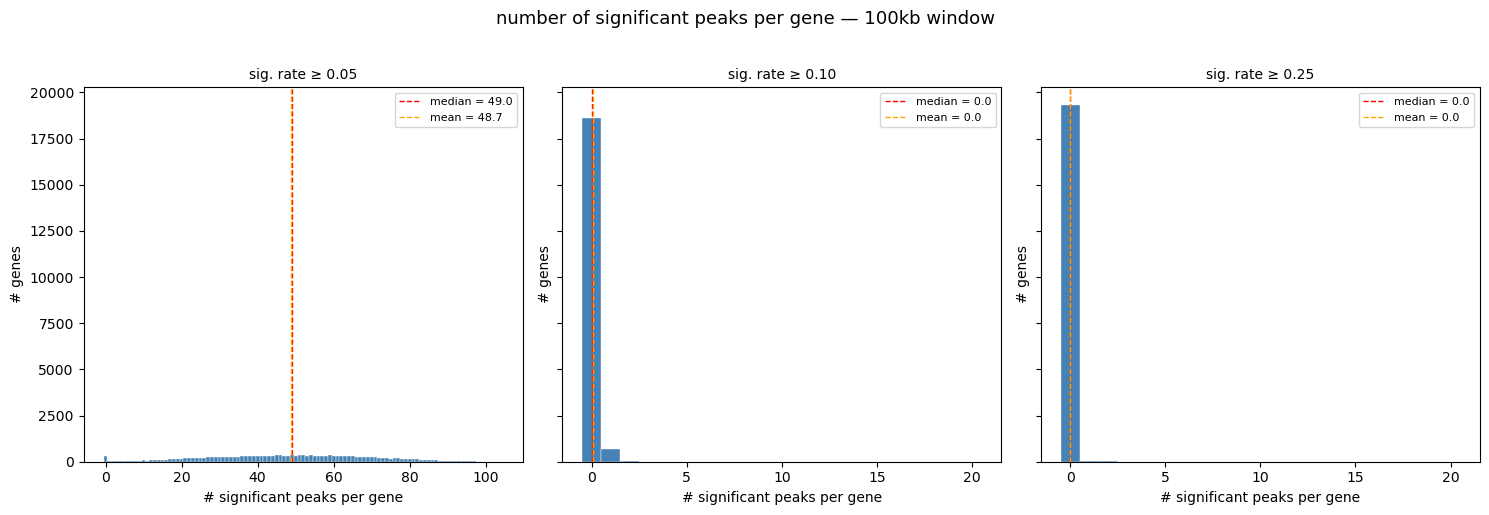

In [26]:
#count significant peaks per gene per window
sig_peaks_per_gene = (
    ols_res_100kb_brief_df
    .groupby(["window", "gene"])
    .agg(
        n_peaks_total        = ("peak", "count"),
        n_significant        = ("significance_rate", lambda x: (x > 0).sum()),
        n_sig_05             = ("significance_rate", lambda x: (x >= 0.05).sum()),
        n_sig_10             = ("significance_rate", lambda x: (x >= 0.10).sum()),
        n_sig_25             = ("significance_rate", lambda x: (x >= 0.25).sum()),
    )
    .reset_index()
)

sig_peaks_per_gene["window"] = pd.Categorical(
    sig_peaks_per_gene["window"],
    categories=["100kb"],
    ordered=True,
)

#plot the number of sig. peaks per gene for 100kb window and thresholds in a grid of histograms
import matplotlib.pyplot as plt

thresholds     = ["n_sig_05", "n_sig_10", "n_sig_25"]
threshold_labs = ["≥ 0.05",   "≥ 0.10",   "≥ 0.25"]
window         = "100kb"

fig, axes = plt.subplots(1, len(thresholds), figsize=(15, 5), sharey=True)

for col_i, (thresh_col, thresh_lab) in enumerate(zip(thresholds, threshold_labs)):
    ax   = axes[col_i]
    data = sig_peaks_per_gene.loc[
        sig_peaks_per_gene["window"] == window, thresh_col
    ]

    ax.hist(
        data,
        bins=range(0, int(data.max()) + 2),
        edgecolor="white",
        linewidth=0.3,
        color="steelblue",
        align="left",
    )

    ax.axvline(data.median(), color="red",    linestyle="--",
               linewidth=1, label=f"median = {data.median():.1f}")
    ax.axvline(data.mean(),   color="orange", linestyle="--",
               linewidth=1, label=f"mean = {data.mean():.1f}")

    ax.set_title(f"sig. rate {thresh_lab}", fontsize=10)
    ax.set_xlabel("# significant peaks per gene")
    ax.set_ylabel("# genes")
    ax.legend(fontsize=8)

plt.suptitle(
    f"number of significant peaks per gene — {window} window",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()

# Sanity check of bootstrapping ols code


In [18]:
# ── configure window ──────────────────────────────────────────────────────────
window_label  = "100kb"
gene_peaks_df = gene_peaks_100kb

# ── result store ──────────────────────────────────────────────────────────────
ols_results = {}

# ── OLS loop per gene ─────────────────────────────────────────────────────────

# index the dataframe once before the loop
gene_peaks_indexed = gene_peaks_df.set_index("gene_id")

for gene_id in gene_peaks_indexed.index:
    assigned_peaks_raw = gene_peaks_indexed.loc[gene_id, "assigned_peaks"]

    if isinstance(assigned_peaks_raw, str):
        assigned_peaks = ast.literal_eval(assigned_peaks_raw)
    else:
        assigned_peaks = list(assigned_peaks_raw)

    assigned_peaks = [p for p in assigned_peaks if p in pb_atac_ct.var_names]

    if len(assigned_peaks) == 0:
        ols_results[gene_id] = {}
        
    print(len(assigned_peaks))

    y = np.asarray(pb_rna_ct[:, gene_id].X).ravel().astype(float)

    if np.std(y) == 0 or y.shape[0] < 2:
        ols_results[gene_id] = {}

    X_raw = np.asarray(pb_atac_ct[:, assigned_peaks].X).astype(float)
    n_samples     = X_raw.shape[0]
    n_peaks_total = X_raw.shape[1]

    peak_means = X_raw.mean(axis=0)
    peak_stds  = X_raw.std(axis=0)

    constant_mask = peak_stds == 0
    if constant_mask.any():
        keep_mask      = ~constant_mask
        assigned_peaks = [p for p, keep in zip(assigned_peaks, keep_mask) if keep]
        X_raw          = X_raw[:, keep_mask]
        peak_means     = peak_means[keep_mask]
        peak_stds      = peak_stds[keep_mask]
        n_peaks_total  = X_raw.shape[1]

    if n_peaks_total == 0:
        ols_results[gene_id] = {}
        

    X_raw = (X_raw - peak_means) / peak_stds

    n_select = max(1, min(n_peaks_total, n_samples - 2))

    significance_threshold = 0.05

    sig_counts  = np.zeros(n_peaks_total, dtype=float)
    iter_counts = np.zeros(n_peaks_total, dtype=float)
    coef_sums   = np.zeros(n_peaks_total, dtype=float)

57
57
61
66
71
74
78
90
106
104
103
104
106
111
111
109
117
116
116
116
116
118
119
116
116
113
112
98
98
99
99
99
99
92
90
92
101
102
104
106
102
102
96
114
109
110
97
94
94
100
100
99
100
102
103
102
105
113
93
83
86
93
97
98
113
109
110
110
110
95
104
89
90
92
99
104
108
110
98
102
109
108
110
109
113
111
114
113
93
101
101
107
101
98
100
97
97
104
109
110
83
110
103
109
107
106
97
96
97
95
94
87
88
88
90
102
102
101
101
98
98
100
100
100
97
99
101
104
102
101
104
104
101
99
87
96
96
96
96
100
99
95
102
102
101
101
104
104
101
102
102
101
97
93
93
93
91
99
92
96
97
92
89
97
100
97
98
97
95
94
98
91
87
85
85
94
94
92
95
93
94
94
95
101
100
101
100
100
104
100
100
97
99
88
94
95
98
93
93
87
85
94
92
88
84
83
78
73
69
102
109
108
109
99
95
97
99
91
93
92
98
105
104
100
94
95
95
98
95
95
95
93
96
95
93
106
68
67
74
86
94
96
95
95
86
86
87
88
90
91
94
93
99
98
96
95
93
90
86
88
87
92
92
92
102
96
95
100
99
90
84
95
95
84
78
64
98
96
97
92
91
92
90
91
97
89
90
89
90
87
90
96
98
102
95
96


In [19]:
X_raw[0:2, 0:2]

array([[-0.01141625, -0.67479251],
       [ 0.09534363, -0.23102599]])

In [20]:
#iter 1
replace = n_peaks_total < n_select
sel_idx = np.random.choice(n_peaks_total, size=n_select, replace=replace)
sel_idx = np.unique(sel_idx)

X_sel = add_constant(X_raw[:, sel_idx], prepend=True)

result  = OLS(y, X_sel).fit()
pvalues = result.pvalues[1:]
coefs   = result.params[1:]

sig_mask = pvalues <= significance_threshold
iter_counts[sel_idx] += 1
sig_counts[sel_idx]  += sig_mask.astype(float)
coef_sums[sel_idx]   += np.where(sig_mask, coefs, 0.0)

print(sel_idx)
print(iter_counts)
print(sig_counts)
print(coef_sums)

[ 0  1  2  3  4  5  6  8  9 10 11 12 14 15 17 18 20 21 22 23 25 26 28 29
 30 31 32 33 34 35 38 41 42 44 45 48 49]
[1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 1. 1.
 0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 1. 0. 0. 1. 1. 0. 1. 1. 0. 0.
 1. 1. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


In [21]:
#iter 2
replace = n_peaks_total < n_select
sel_idx = np.random.choice(n_peaks_total, size=n_select, replace=replace)
sel_idx = np.unique(sel_idx)

X_sel = add_constant(X_raw[:, sel_idx], prepend=True)

result  = OLS(y, X_sel).fit()
pvalues = result.pvalues[1:]
coefs   = result.params[1:]

sig_mask = pvalues <= significance_threshold
iter_counts[sel_idx] += 1
sig_counts[sel_idx]  += sig_mask.astype(float)
coef_sums[sel_idx]   += np.where(sig_mask, coefs, 0.0)

print(sel_idx)
print(iter_counts)
print(sig_counts)
print(coef_sums)

[ 1  2  4  5  6 11 13 14 15 16 17 19 20 21 22 23 24 25 26 27 28 31 33 34
 35 36 37 38 39 41 42 43 45 46 48 49 51]
[1. 2. 2. 1. 2. 2. 2. 0. 1. 1. 1. 2. 1. 1. 2. 2. 1. 2. 1. 1. 2. 2. 2. 2.
 1. 2. 2. 1. 2. 1. 1. 2. 1. 2. 2. 2. 1. 1. 2. 1. 0. 2. 2. 1. 1. 2. 1. 0.
 2. 2. 0. 1.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


In [22]:
#iter 3
replace = n_peaks_total < n_select
sel_idx = np.random.choice(n_peaks_total, size=n_select, replace=replace)
sel_idx = np.unique(sel_idx)

X_sel = add_constant(X_raw[:, sel_idx], prepend=True)

result  = OLS(y, X_sel).fit()
pvalues = result.pvalues[1:]
coefs   = result.params[1:]

sig_mask = pvalues <= significance_threshold
iter_counts[sel_idx] += 1
sig_counts[sel_idx]  += sig_mask.astype(float)
coef_sums[sel_idx]   += np.where(sig_mask, coefs, 0.0)

print(sel_idx)
print(iter_counts)
print(sig_counts)
print(coef_sums)

[ 0  1  3  4  5  6  7  8  9 11 12 13 16 18 20 21 22 23 24 25 26 29 30 31
 32 33 35 37 38 41 43 44 47 48 49 50 51]
[2. 3. 2. 2. 3. 3. 3. 1. 2. 2. 1. 3. 2. 2. 2. 2. 2. 2. 2. 1. 3. 3. 3. 3.
 2. 3. 3. 1. 2. 2. 2. 3. 2. 3. 2. 3. 1. 2. 3. 1. 0. 3. 2. 2. 2. 2. 1. 1.
 3. 3. 1. 2.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


In [23]:
peak_i = 48
n_iter = iter_counts[peak_i]
n_sig  = sig_counts[peak_i]

print(f"Peak index: {peak_i}, times sampled: {n_iter}, times significant: {n_sig}, significance rate: {n_sig / n_iter if n_iter > 0 else 0:.2f}, mean coef if significant: {coef_sums[peak_i] / n_sig if n_sig > 0 else np.nan:.4f}")
peak_i

Peak index: 48, times sampled: 3.0, times significant: 0.0, significance rate: 0.00, mean coef if significant: nan


48

In [24]:
peak_id = 6
n_iter = iter_counts[peak_i]
n_sig  = sig_counts[peak_i]

print(f"Peak index: {peak_i}, times sampled: {n_iter}, times significant: {n_sig}, significance rate: {n_sig / n_iter if n_iter > 0 else 0:.2f}, mean coef if significant: {coef_sums[peak_i] / n_sig if n_sig > 0 else np.nan:.4f}")
peak_i

Peak index: 48, times sampled: 3.0, times significant: 0.0, significance rate: 0.00, mean coef if significant: nan


48

In [25]:
peak_summaries = {}

peak_summaries[assigned_peaks[peak_i]] = {
        "times_sampled":            int(n_iter),
        "times_significant":        int(n_sig),
        # a) fraction of iterations where peak was significant
        "significance_rate":        n_sig / n_iter,
        # b) average coefficient across iterations where peak WAS significant
            #    (NaN if never significant — no coefs to average)
        "mean_coef_if_significant": coef_sums[peak_i] / n_sig if n_sig > 0 else np.nan,
    }

peak_summaries

{'25-37497049-37497789': {'times_sampled': 3,
  'times_significant': 0,
  'significance_rate': 0.0,
  'mean_coef_if_significant': nan}}

## Summarizing bootstrap ols results across all windows

In [21]:
# summarizing all brief ols results into a dataframe
ols_res_all_windows_brief_df = pd.concat(
    [
        ols_res_10kb_brief_df,
        ols_res_20kb_brief_df,
        ols_res_50kb_brief_df,
        ols_res_100kb_brief_df,
    ],
    ignore_index=True,
)

ols_res_all_windows_brief_df["window"] = pd.Categorical(
    ols_res_all_windows_brief_df["window"],
    categories=["10kb", "20kb", "50kb", "100kb"],
    ordered=True,
)

print(f"Combined DataFrame: {ols_res_all_windows_brief_df.shape[0]:,} peak–gene pairs")
print(f"Windows: {ols_res_all_windows_brief_df['window'].value_counts().sort_index()}")
print(ols_res_all_windows_brief_df.head())

#save the combined dataframe to a csv file
ols_res_all_windows_brief_df.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/ols_bootstrap_brief_ct_results.csv.gz", index=False)

Combined DataFrame: 3,340,927 peak–gene pairs
Windows: window
10kb      173645
20kb      363753
50kb      931642
100kb    1871887
Name: count, dtype: int64
  window   gene           peak  n_samples  n_peaks_total  n_select  \
0   10kb  rpl24    1-2372-3057         39             13        13   
1   10kb  rpl24    1-3427-4032         39             13        13   
2   10kb  rpl24    1-4469-7268         39             13        13   
3   10kb  rpl24    1-9541-9969         39             13        13   
4   10kb  rpl24  1-11007-12962         39             13        13   

   n_iterations  times_sampled  times_significant  significance_rate  \
0           100            100                  0                0.0   
1           100            100                  0                0.0   
2           100            100                100                1.0   
3           100            100                  0                0.0   
4           100            100                  0              

In [22]:
#count significant peaks per gene per window
sig_peaks_per_gene = (
    ols_res_all_windows_brief_df
    .groupby(["window", "gene"])
    .agg(
        n_peaks_total        = ("peak", "count"),
        n_significant        = ("significance_rate", lambda x: (x > 0).sum()),
        n_sig_05             = ("significance_rate", lambda x: (x >= 0.05).sum()),
        n_sig_10             = ("significance_rate", lambda x: (x >= 0.10).sum()),
        n_sig_25             = ("significance_rate", lambda x: (x >= 0.25).sum()),
    )
    .reset_index()
)

sig_peaks_per_gene["window"] = pd.Categorical(
    sig_peaks_per_gene["window"],
    categories=["10kb", "20kb", "50kb", "100kb"],
    ordered=True,
)

print(sig_peaks_per_gene.head(20))

/tmp/ipykernel_3414865/3403716294.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["window", "gene"])


   window      gene  n_peaks_total  n_significant  n_sig_05  n_sig_10  \
0    10kb      a1cf             11            1.0       1.0       1.0   
1    10kb      a2ml             11            1.0       1.0       1.0   
2    10kb      aaas              6            1.0       1.0       1.0   
3    10kb      aacs             10            3.0       3.0       3.0   
4    10kb     aadac              9            0.0       0.0       0.0   
5    10kb   aadacl4             10            2.0       2.0       2.0   
6    10kb     aadat              9            1.0       1.0       1.0   
7    10kb     aagab              7            3.0       3.0       3.0   
8    10kb     aak1a              9            2.0       2.0       2.0   
9    10kb     aak1b              9            3.0       3.0       3.0   
10   10kb     aamdc              7            1.0       1.0       1.0   
11   10kb      aamp              7            4.0       4.0       4.0   
12   10kb    aanat1              7            1.0  

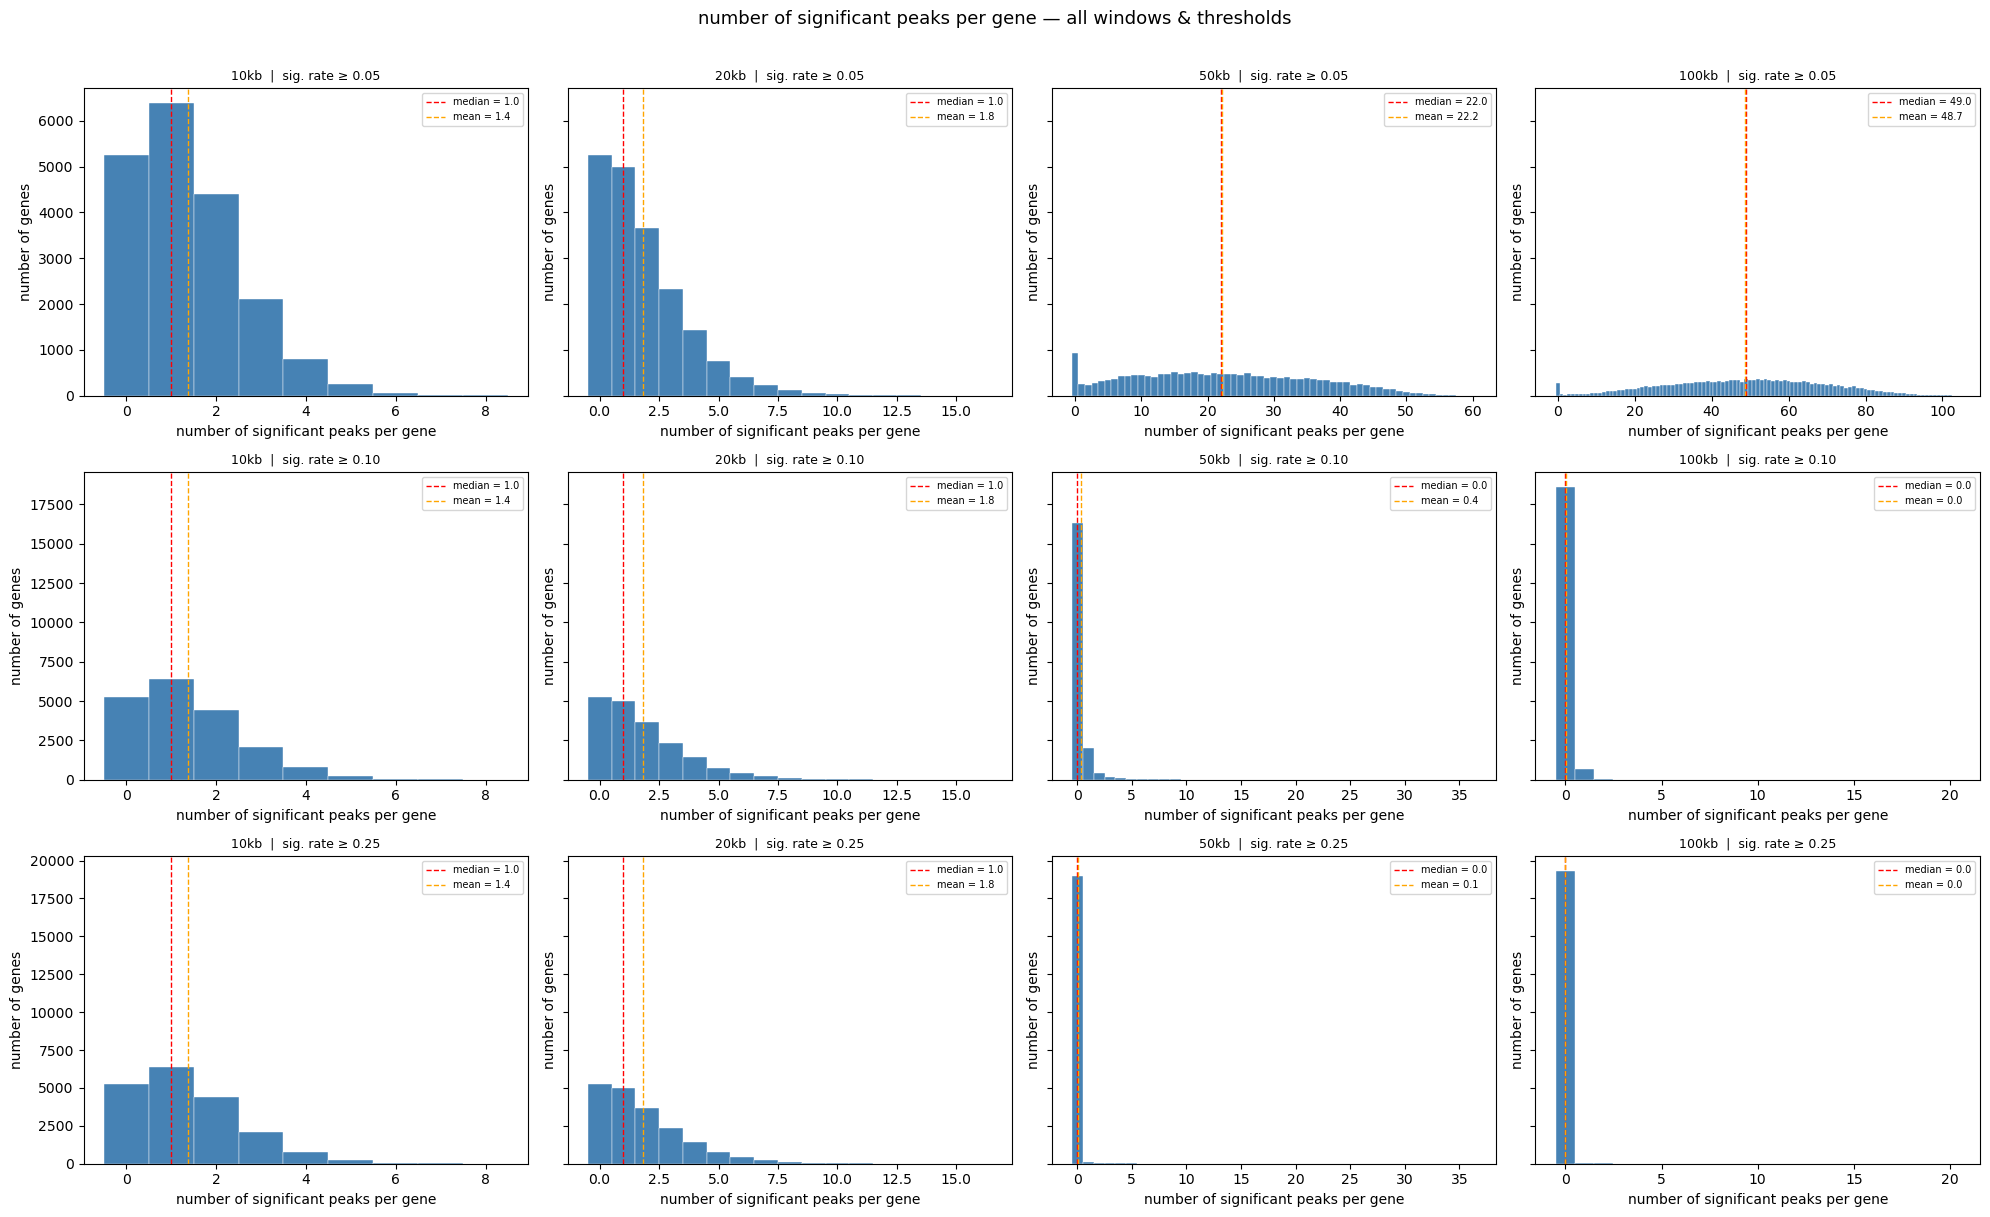

In [23]:
#plot the number of sig. peaks per gene across windows and thresholds in a grid of histograms
import matplotlib.pyplot as plt

thresholds     = ["n_sig_05", "n_sig_10", "n_sig_25"]
threshold_labs = ["≥ 0.05", "≥ 0.10", "≥ 0.25"]
windows        = ["10kb", "20kb", "50kb", "100kb"]

fig, axes = plt.subplots(
    len(thresholds), len(windows),
    figsize=(20, 12),
    sharey="row",   # same y scale across windows within a threshold row
)

for row_i, (thresh_col, thresh_lab) in enumerate(zip(thresholds, threshold_labs)):
    for col_i, window in enumerate(windows):
        ax = axes[row_i, col_i]

        data = sig_peaks_per_gene.loc[
            sig_peaks_per_gene["window"] == window, thresh_col
        ]

        ax.hist(
            data,
            bins=range(0, int(data.max()) + 2),
            edgecolor="white",
            linewidth=0.3,
            color="steelblue",
            align="left",
            )

        ax.axvline(data.median(), color="red",    linestyle="--",
                   linewidth=1, label=f"median = {data.median():.1f}")
        ax.axvline(data.mean(),   color="orange", linestyle="--",
                   linewidth=1, label=f"mean = {data.mean():.1f}")

        ax.set_title(f"{window}  |  sig. rate {thresh_lab}", fontsize=9)
        ax.set_xlabel("number of significant peaks per gene")
        ax.set_ylabel("number of genes")
        ax.legend(fontsize=7)

plt.suptitle(
    "number of significant peaks per gene — all windows & thresholds",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()

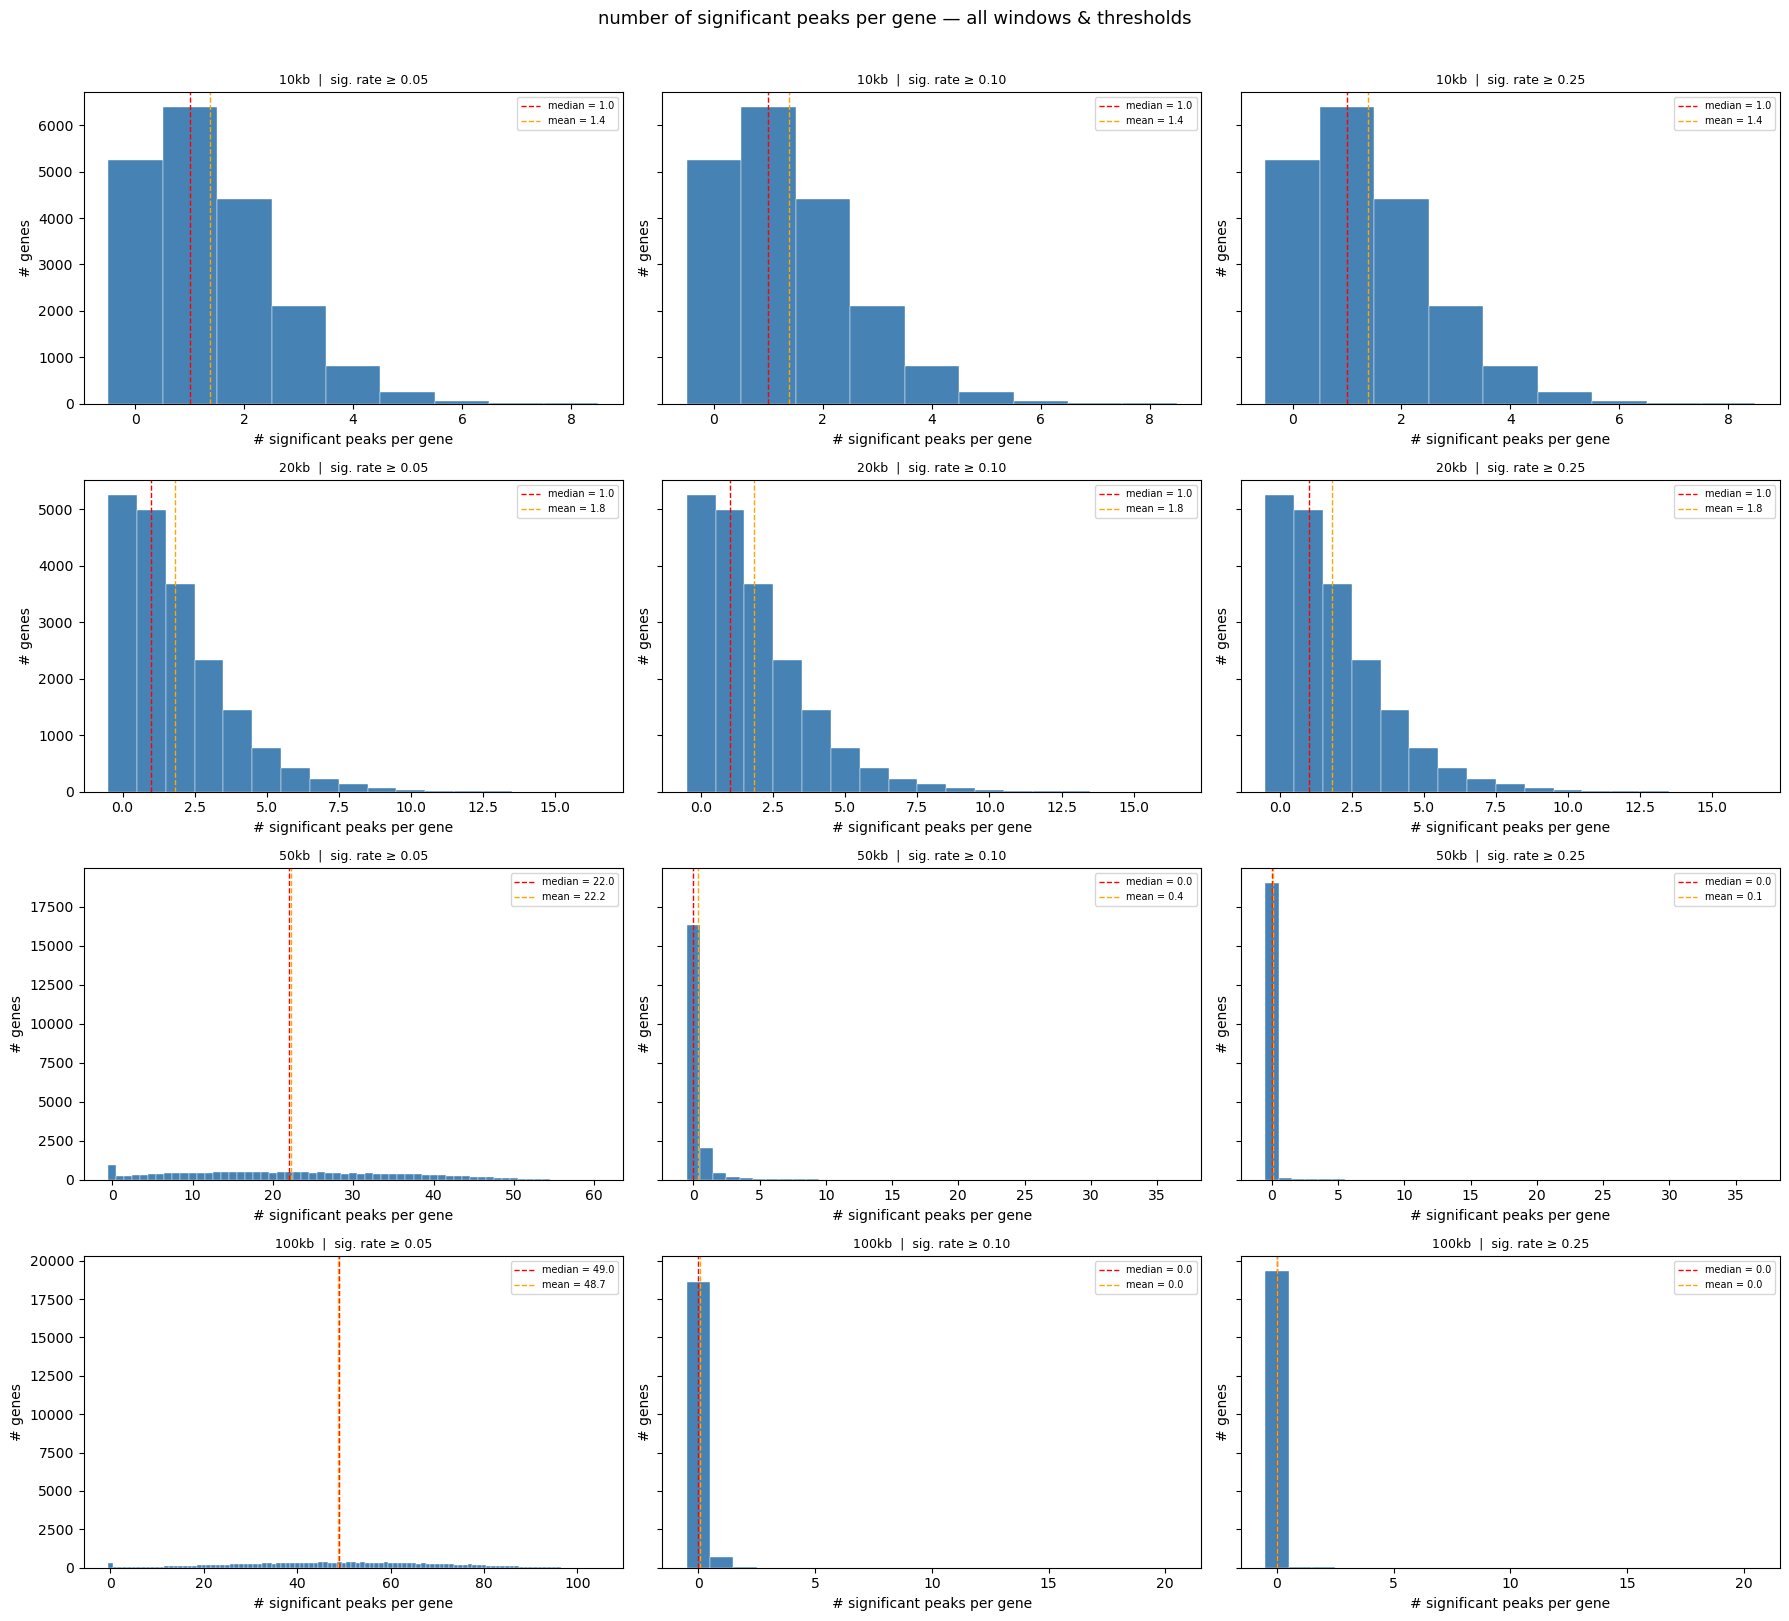

In [24]:
#same plot but row = windows & col = thresholds
import matplotlib.pyplot as plt

thresholds     = ["n_sig_05", "n_sig_10", "n_sig_25"]
threshold_labs = ["≥ 0.05",   "≥ 0.10",   "≥ 0.25"]
windows        = ["10kb", "20kb", "50kb", "100kb"]

fig, axes = plt.subplots(
    len(windows), len(thresholds),
    figsize=(18, 16),
    sharey="row",   # same y scale across thresholds within a window row
)

for row_i, window in enumerate(windows):
    for col_i, (thresh_col, thresh_lab) in enumerate(zip(thresholds, threshold_labs)):
        ax = axes[row_i, col_i]

        data = sig_peaks_per_gene.loc[
            sig_peaks_per_gene["window"] == window, thresh_col
        ]

        ax.hist(
            data,
            bins=range(0, int(data.max()) + 2),
            edgecolor="white",
            linewidth=0.3,
            color="steelblue",
            align="left",
        )

        ax.axvline(data.median(), color="red",    linestyle="--",
                   linewidth=1, label=f"median = {data.median():.1f}")
        ax.axvline(data.mean(),   color="orange", linestyle="--",
                   linewidth=1, label=f"mean = {data.mean():.1f}")

        ax.set_title(f"{window}  |  sig. rate {thresh_lab}", fontsize=9)
        ax.set_xlabel("# significant peaks per gene")
        ax.set_ylabel("# genes")
        ax.legend(fontsize=7)

plt.suptitle(
    "number of significant peaks per gene — all windows & thresholds",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()

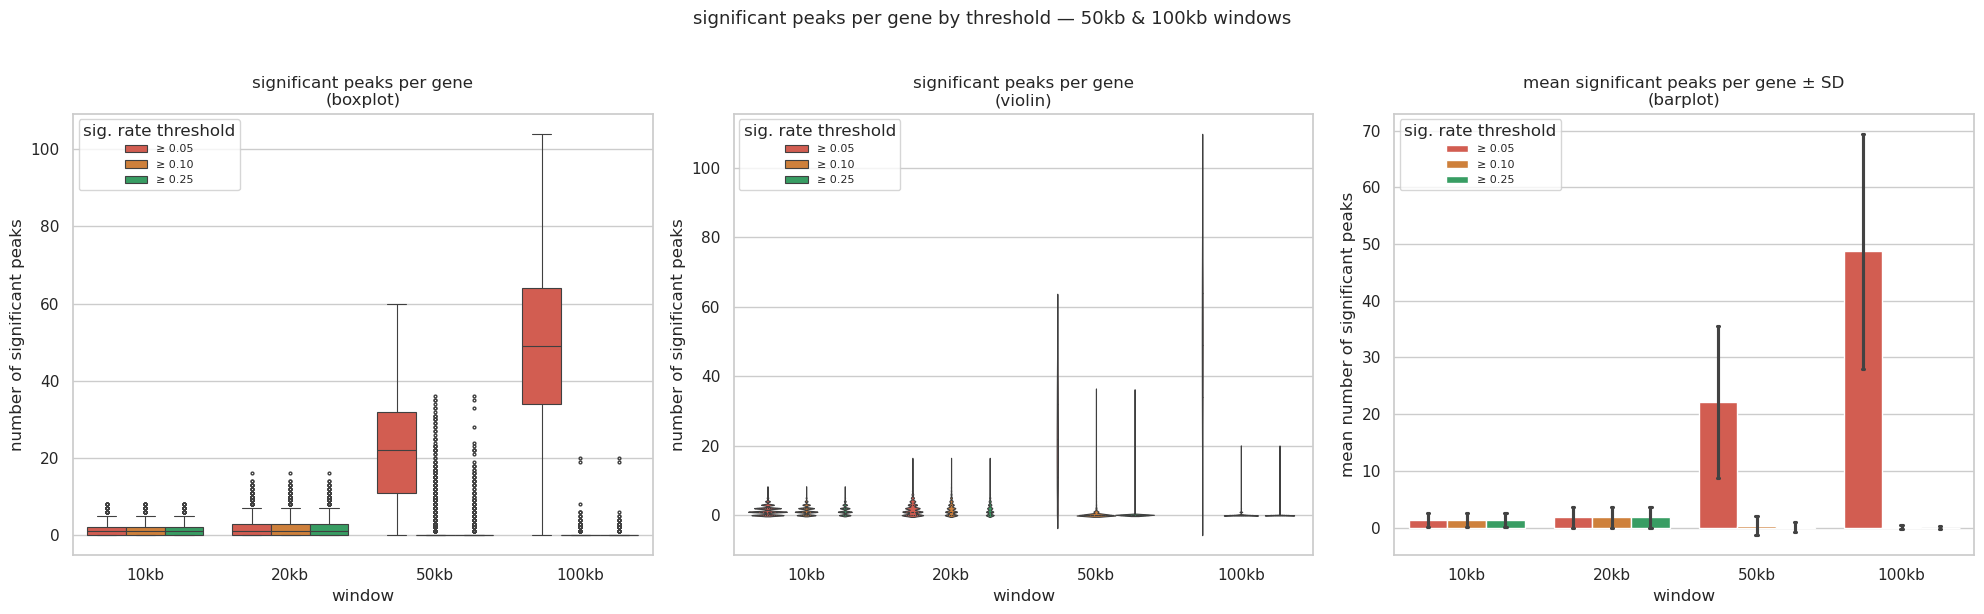

In [ ]:
#number of peaks per gene across windows and thresholds in boxplots
import seaborn as sns
import matplotlib.pyplot as plt

# melt to long format so seaborn can split by threshold
sig_peaks_long = sig_peaks_per_gene.melt(
    id_vars=["window", "gene", "n_peaks_total"],
    value_vars=["n_sig_05", "n_sig_10", "n_sig_25"],
    var_name="threshold",
    value_name="n_sig",        # ← renamed to avoid clash with existing column
)

# make threshold labels readable
sig_peaks_long["threshold"] = sig_peaks_long["threshold"].map({
    "n_sig_05": "≥ 0.05",
    "n_sig_10": "≥ 0.10",
    "n_sig_25": "≥ 0.25",
})

windows = ["50kb", "100kb"]

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

for col_i, window in enumerate(windows):
    ax = axes[col_i]

    data = sig_peaks_long[sig_peaks_long["window"] == window]

# ── 1. boxplot: n significant peaks per gene, by window and threshold ─────────
sns.boxplot(
    data=sig_peaks_long,
    x="window", y="n_sig", hue="threshold",
    palette=["#e74c3c", "#e67e22", "#27ae60"],
    linewidth=0.8, fliersize=2,
    ax=axes[0],
)
axes[0].set_title("significant peaks per gene\n(boxplot)")
axes[0].set_xlabel("window")
axes[0].set_ylabel("number of significant peaks")
axes[0].legend(title="sig. rate threshold", fontsize=8)

# ── 2. violinplot: distribution shape per window and threshold ─────────────────
sns.violinplot(
    data=sig_peaks_long,
    x="window", y="n_sig", hue="threshold",
    palette=["#e74c3c", "#e67e22", "#27ae60"],
    linewidth=0.8, inner="quartile",
    ax=axes[1],
)
axes[1].set_title("significant peaks per gene\n(violin)")
axes[1].set_xlabel("window")
axes[1].set_ylabel("number of significant peaks")
axes[1].legend(title="sig. rate threshold", fontsize=8)

# ── 3. barplot: mean n significant peaks per gene, by window and threshold ─────
sns.barplot(
    data=sig_peaks_long,
    x="window", y="n_sig", hue="threshold",
    palette=["#e74c3c", "#e67e22", "#27ae60"],
    errorbar="sd", capsize=0.05,
    ax=axes[2],
)
axes[2].set_title("mean significant peaks per gene ± SD\n(barplot)")
axes[2].set_xlabel("window")
axes[2].set_ylabel("mean number of significant peaks")
axes[2].legend(title="sig. rate threshold", fontsize=8)

plt.suptitle(
    "significant peaks per gene by threshold (ct)",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()

## combining results of normal ols and bootstrapping ols
normal ols => 10kb, 20kb 

bootstrapping ols => 50kb, 100kb

In [3]:
#read in the full brief results dataframe and filter for 100kb window and significance rate ≥ 0.05
ols_res_all_windows_brief_df = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_bootstrap_brief_ct_results.csv.gz")
ols_100kb_sig05_df = ols_res_all_windows_brief_df[
    (ols_res_all_windows_brief_df["window"] == "100kb") &
    (ols_res_all_windows_brief_df["significance_rate"] >= 0.05)
]   

ols_50kb_sig05_df = ols_res_all_windows_brief_df[
    (ols_res_all_windows_brief_df["window"] == "50kb") &
    (ols_res_all_windows_brief_df["significance_rate"] >= 0.05)
]

#copy only the columns "gene", "peak", "significance_rate", "mean_coef_if_significant" from ols_100kb_sig05_df to a new dataframe
ols_100kb_sig05_df = ols_100kb_sig05_df[
    ["window", "gene", "peak", "significance_rate", "mean_coef_if_significant"]
]

ols_50kb_sig05_df = ols_50kb_sig05_df[
    ["window", "gene", "peak", "significance_rate", "mean_coef_if_significant"]
]

# classify every peak–gene pair into one of three categories
def classify_pair(row):
    if row["significance_rate"] >= 0.05 and row["mean_coef_if_significant"] < 0:
        return "sig. negative"
    elif row["significance_rate"] >= 0.05 and row["mean_coef_if_significant"] > 0:
        return "sig. positive"
    else:
        return "non-significant"
    
ols_100kb_sig05_df["category"] = ols_100kb_sig05_df.apply(classify_pair, axis=1)
ols_50kb_sig05_df["category"] = ols_50kb_sig05_df.apply(classify_pair, axis=1)
print(ols_100kb_sig05_df.head())
print(ols_50kb_sig05_df.head())

#aggregate the number of significant peaks per gene and category  
agg_ols_100kb_sig05_df = (
    ols_100kb_sig05_df
    .dropna(subset=["mean_coef_if_significant", "significance_rate", "category"])
    .groupby(["window", "gene", "category"])
    .size()
    .reset_index(name="count")
)

agg_ols_50kb_sig05_df = (
    ols_50kb_sig05_df
    .dropna(subset=["mean_coef_if_significant", "significance_rate", "category"])
    .groupby(["window", "gene", "category"])
    .size()
    .reset_index(name="count")
)

print(agg_ols_100kb_sig05_df.head())
print(agg_ols_50kb_sig05_df.head())

        window   gene           peak  significance_rate  \
1469041  100kb  rpl24    1-2372-3057           0.063272   
1469042  100kb  rpl24    1-3427-4032           0.062600   
1469043  100kb  rpl24    1-4469-7268           0.066358   
1469044  100kb  rpl24    1-9541-9969           0.052885   
1469045  100kb  rpl24  1-11007-12962           0.061633   

         mean_coef_if_significant       category  
1469041                  0.015684  sig. positive  
1469042                 -0.026589  sig. negative  
1469043                 -0.031779  sig. negative  
1469044                 -0.025713  sig. negative  
1469045                  0.053095  sig. positive  
       window   gene           peak  significance_rate  \
537409   50kb  rpl24  1-17587-18215                1.0   
537422   50kb  rpl24  1-43295-45665                1.0   
537429   50kb  cep97       1-32-526                1.0   
537435   50kb  cep97  1-13276-13705                1.0   
537436   50kb  cep97  1-14059-14260              

In [4]:
#read in the ols results dataframe for 10kb and 20kb windows
ols_10kb_df = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_res_10kb_df_ct.csv")
ols_20kb_df = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_res_20kb_df_ct.csv")

print(ols_10kb_df.head())
print(ols_20kb_df.head())


#aggregate the number of significant peaks per gene and category  

agg_ols_10kb_df = (
    ols_10kb_df
    .dropna(subset=["coef", "pval", "category"]) 
    .groupby(["window", "gene", "category"]) 
    .size()
    .reset_index(name="count")
)

agg_ols_20kb_df = (
    ols_20kb_df
    .dropna(subset=["coef", "pval", "category"]) 
    .groupby(["window", "gene", "category"]) 
    .size()
    .reset_index(name="count")
)

print(agg_ols_10kb_df.head())
print(agg_ols_20kb_df.head())

  window   gene           peak      coef      pval         category
0   10kb  rpl24    1-2372-3057  0.010627  0.210658  non-significant
1   10kb  rpl24    1-3427-4032 -0.000448  0.956809  non-significant
2   10kb  rpl24    1-4469-7268 -0.033500  0.031205    sig. negative
3   10kb  rpl24    1-9541-9969 -0.018306  0.098417  non-significant
4   10kb  rpl24  1-11007-12962  0.020210  0.132102  non-significant
  window   gene         peak      coef      pval         category
0   20kb  rpl24     1-32-526 -0.002326  0.724209  non-significant
1   20kb  rpl24  1-2372-3057 -0.000544  0.957907  non-significant
2   20kb  rpl24  1-3427-4032  0.004486  0.636083  non-significant
3   20kb  rpl24  1-4469-7268 -0.035735  0.040825    sig. negative
4   20kb  rpl24  1-9541-9969 -0.018420  0.151080  non-significant
  window  gene         category  count
0   10kb  a1cf  non-significant     10
1   10kb  a1cf    sig. positive      1
2   10kb  a2ml  non-significant     10
3   10kb  a2ml    sig. positive      1
4

In [ ]:
#combine all aggregated dataframes into one dataframe and make sure the "window" column is categorical with the correct order
agg_ols_all_windows_df = pd.concat(
    [
        agg_ols_10kb_df,
        agg_ols_20kb_df,
        agg_ols_50kb_sig05_df,
        agg_ols_100kb_sig05_df,
    ],
    ignore_index=True,
)   
agg_ols_all_windows_df["window"] = pd.Categorical( 
    agg_ols_all_windows_df["window"],
    categories=["10kb", "20kb", "50kb", "100kb"],
    ordered=True,
)

print(agg_ols_all_windows_df["window"].unique())

['10kb', '20kb', '50kb', '100kb']
Categories (4, object): ['10kb' < '20kb' < '50kb' < '100kb']


In [7]:
#combine  ols_10kb_df, ols_20kb_df, ols_50kb_sig05_df and ols_100kb_sig05_df into one dataframe with only the columns "window", "gene", "peak", "significance_rate", "mean_coef_if_significant" and "category"

#rename the column in ols_50kb_sig05_df from "significance_rate" to "sig_rate" and "mean_coef_if_significant" to "mean_coef_sig" to avoid confusion with the columns in ols_10kb_df and ols_20kb_df
ols_50kb_df = ols_50kb_sig05_df.rename(columns={"significance_rate": "pval", "mean_coef_if_significant": "coef"})
ols_100kb_df = ols_100kb_sig05_df.rename(columns={"significance_rate": "pval", "mean_coef_if_significant": "coef"})

ols_all_windows_df = pd.concat(
    [
        ols_10kb_df,
        ols_20kb_df,
        ols_50kb_df,
        ols_100kb_df,
    ],
    ignore_index=True,
)  

#save the combined dataframe to a csv file
ols_all_windows_df.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_res_all_windows_df_ct.csv", index=False)

## Dedublication of ols results across windows

In [6]:
#read in the combined dataframe and make sure the "window" column is categorical with the correct order
ols_all_df = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_res_all_windows_df_ct.csv")
ols_all_df.head()

# Make window categorical and ordered
ols_all_df["window"] = pd.Categorical(
    ols_all_df["window"],
    categories=["10kb", "20kb", "50kb", "100kb"],
    ordered=True
)

# Order by window
ols_all_df = ols_all_df.sort_values("window",ascending=True)
print(ols_all_df[["window", "gene", "peak", "coef", "pval", "category"]].head())

#"Dedublication" of gene-peak pairs by keeping only the first occurrence of each pair across all windows (since they are ordered by window size, this will keep the pair with the smallest window size)"
pair_summary = (
    ols_all_df
    .groupby(["gene", "peak"], as_index=False)
    .first()
)

#Sort by window to keep the smallest window size for each gene-peak pair
pair_summary = pair_summary.sort_values("window", ascending=True)
print(pair_summary[["window", "gene", "peak", "coef", "pval", "category"]].head())

#Sanity check to confirm that each gene-peak pair is now unique
pair_counts = pair_summary.groupby(["gene", "peak"]).size().reset_index(name="count")
print(pair_counts['count'].value_counts()) # Should show that all pairs have a count of 1

#Counts how many unique gene-peak pairs fall into each category for each window size
summary_counts = (pair_summary.groupby(["window", "gene", "category"]).size().reset_index(name="count"))
summary_counts.head()


       window        gene                  peak      coef      pval  \
0        10kb       rpl24           1-2372-3057  0.010627  0.210658   
115759   10kb  zgc:174938  16-46563683-46564283 -0.000161  0.995271   
115760   10kb  zgc:174938  16-46566746-46567106  0.046478  0.088460   
115761   10kb  zgc:174938  16-46568440-46568768  0.066503  0.067081   
115762   10kb  zgc:174938  16-46569032-46570598 -0.058933  0.147374   

               category  
0       non-significant  
115759  non-significant  
115760  non-significant  
115761  non-significant  
115762  non-significant  
       window     gene                  peak      coef      pval  \
830475   10kb   rxylt1  18-13126062-13126886  0.002987  0.907865   
148718   10kb  cdc14ab  22-16276821-16277476  0.038473  0.138977   
148719   10kb  cdc14ab  22-16277779-16278375 -0.012926  0.531179   
148720   10kb  cdc14ab  22-16278775-16279560 -0.029056  0.414713   
298680   10kb   ephb4b  23-44356912-44357397  0.180813  0.000203   

        

/tmp/ipykernel_3617074/3987943330.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_counts = (pair_summary.groupby(["window", "gene", "category"]).size().reset_index(name="count"))


,window,gene,category,count
0,10kb,a1cf,non-significant,10
1,10kb,a1cf,sig. negative,0
2,10kb,a1cf,sig. positive,1
3,10kb,a2ml,non-significant,10
4,10kb,a2ml,sig. negative,0


/tmp/ipykernel_3617074/2242807746.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([window_labels[t.get_text()] for t in ax.get_xticklabels()])


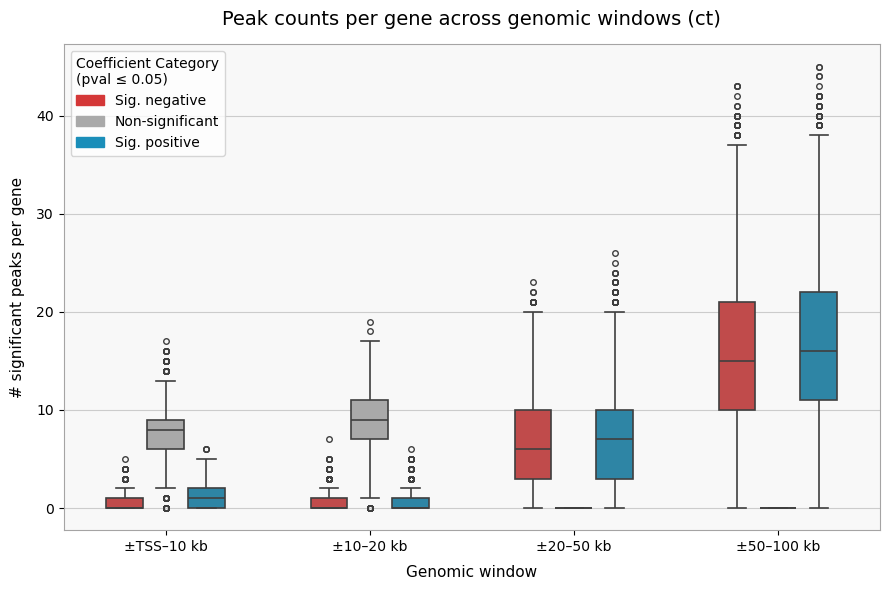

In [7]:
#Boxplot of the counts of peaks per gene (first occurrence of gene-peak pair across all windows) for each category and window size
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

category_order  = ["sig. negative", "non-significant", "sig. positive"]
category_colors = {
    "sig. negative":   "#D43737",
    "sig. positive":   "#1A8EB9",
    "non-significant": "#A9A9A9",
}

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F8F8F8")

sns.boxplot(
    data=summary_counts,
    x="window", y="count", hue="category",
    hue_order=category_order,
    palette=category_colors,
    width=0.6,
    linewidth=1.2,
    fill=True,
    flierprops=dict(marker="o", markersize=4, linewidth=0),
    boxprops=dict(alpha=1),
    gap=0.1,
    ax=ax,
)

# Replace x-axis tick labels
window_labels = {
    "10kb":  "±TSS–10 kb",
    "20kb":  "±10–20 kb",
    "50kb":  "±20–50 kb",
    "100kb": "±50–100 kb",
}
ax.set_xticklabels([window_labels[t.get_text()] for t in ax.get_xticklabels()])

# Recolor fliers manually to match their box color
for line, color in zip(
    [c for c in ax.get_lines() if c.get_linestyle() == "none"],
    [category_colors[cat]
     for _ in summary_counts["window"].cat.categories
     for cat in category_order]
):
    line.set_markerfacecolor(color)
    line.set_markeredgecolor(color)
    line.set_alpha(0.7)

ax.set_title("Peak counts per gene across genomic windows (ct)",
             fontsize=14, fontweight="500", pad=14, loc="center")
ax.set_xlabel("Genomic window", fontsize=11, labelpad=8)
ax.set_ylabel("# significant peaks per gene", fontsize=11, labelpad=8)

ax.yaxis.grid(True, color="#cccccc", linewidth=0.8, linestyle="-", zorder=0)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_color("#a5a4a4")

handles = [mpatches.Patch(color=category_colors[c], alpha=1, label=c.capitalize())
           for c in category_order]
ax.legend(
    handles=handles,
    title="Coefficient Category\n(pval ≤ 0.05)",
    frameon=True,
    fontsize=10,
    loc="upper left",
    title_fontsize=10,
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_3617074/2703788064.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([window_labels[t.get_text()] for t in ax.get_xticklabels()])


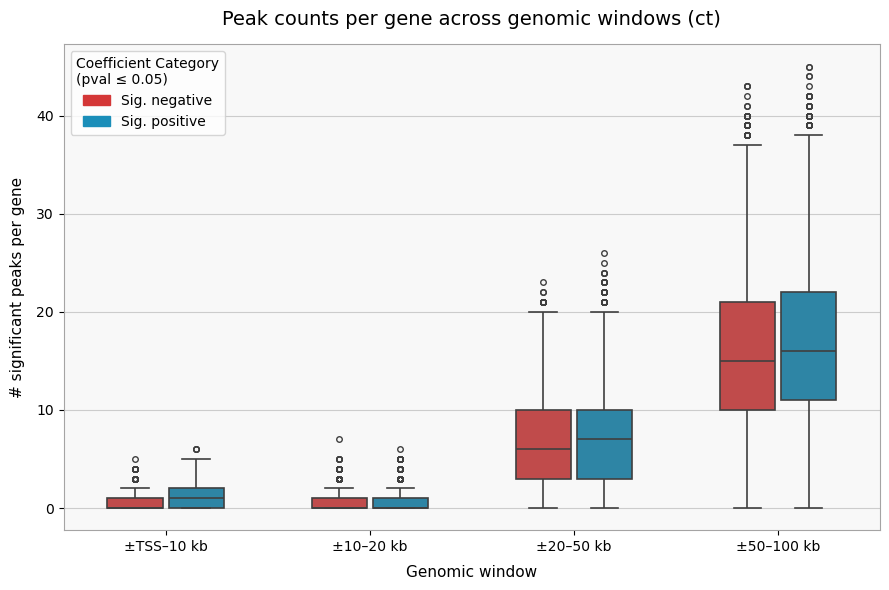

In [8]:
# Boxplot of the counts of peaks per gene (first occurrence of gene-peak pair across all windows) for significant categories only (non-significant category excluded) for each window size
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

category_order  = ["sig. negative", "sig. positive"]
category_colors = {
    "sig. negative":   "#D43737",
    "sig. positive":   "#1A8EB9",
}

only_sig = summary_counts[summary_counts["category"] != "non-significant"]

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F8F8F8")

sns.boxplot(
    data=only_sig,
    x="window", y="count", hue="category",
    hue_order=category_order,
    palette=category_colors,
    width=0.6,
    linewidth=1.2,
    fill=True,
    flierprops=dict(marker="o", markersize=4, linewidth=0),
    boxprops=dict(alpha=1),
    gap=0.1,
    ax=ax,
)

# Replace x-axis tick labels
window_labels = {
    "10kb":  "±TSS–10 kb",
    "20kb":  "±10–20 kb",
    "50kb":  "±20–50 kb",
    "100kb": "±50–100 kb",
}
ax.set_xticklabels([window_labels[t.get_text()] for t in ax.get_xticklabels()])

# Recolor fliers manually to match their box color
for line, color in zip(
    [c for c in ax.get_lines() if c.get_linestyle() == "none"],
    [category_colors[cat]
     for _ in only_sig["window"].cat.categories
     for cat in category_order]
):
    line.set_markerfacecolor(color)
    line.set_markeredgecolor(color)
    line.set_alpha(0.7)

ax.set_title("Peak counts per gene across genomic windows (ct)",
             fontsize=14, fontweight="500", pad=14, loc="center")
ax.set_xlabel("Genomic window", fontsize=11, labelpad=8)
ax.set_ylabel("# significant peaks per gene", fontsize=11, labelpad=8)

ax.yaxis.grid(True, color="#cccccc", linewidth=0.8, linestyle="-", zorder=0)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_color("#a5a4a4")

handles = [mpatches.Patch(color=category_colors[c], alpha=1, label=c.capitalize())
           for c in category_order]
ax.legend(
    handles=handles,
    title="Coefficient Category\n(pval ≤ 0.05)",
    frameon=True,
    fontsize=10,
    loc="upper left",
    title_fontsize=10,
)

plt.tight_layout()
plt.show()

## Combining ols results with correlation results

In [41]:
#read in the results from correlation analysis, then aggregate
cor_res_df = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Results/gene_peak_correlation_ct_results.csv.gz")
cor_res_df.head()

# classify every peak–gene pair into one of three categories
def classify_pair(row):
    if row["padj"] <= 0.05 and row["correlation"] < 0:
        return "sig. negative"
    elif row["padj"] <= 0.05 and row["correlation"] > 0:
        return "sig. positive"
    else:
        return "non-significant"

cor_res_df["category"] = cor_res_df.apply(classify_pair, axis=1)

#aggregate the number of significant peaks per gene and category  
agg_cor_all_windows_df = (
    cor_res_df
    .dropna(subset=["correlation", "padj", "category"])
    .groupby(["window", "gene", "category"])
    .size()
    .reset_index(name="count")
)
agg_cor_all_windows_df.head()

,window,gene,category,count
0,100kb,a1cf,non-significant,87
1,100kb,a1cf,sig. positive,8
2,100kb,a2ml,non-significant,73
3,100kb,a2ml,sig. negative,1
4,100kb,a2ml,sig. positive,3


In [42]:
#merge the two aggregated dataframes on window, gene to compare the number of significant peaks per gene and category between correlation and OLS results

#rename the count column in agg_cor_all_windows_df to count_cor to avoid confusion with the count column in agg_ols_all_windows_df
agg_cor_all_windows_df["count_cor"] = agg_cor_all_windows_df['count']
agg_ols_all_windows_df["count_ols"] = agg_ols_all_windows_df['count']

agg_merged_df = pd.merge(
    agg_cor_all_windows_df,
    agg_ols_all_windows_df,
    on=["window", "gene", "category"],
    how="outer",
)
agg_merged_df.head() 

,window,gene,category,count_x,count_cor,count_y,count_ols
0,100kb,a1cf,non-significant,87.0,87.0,NaN,NaN
1,100kb,a1cf,sig. negative,NaN,NaN,15.0,15.0
2,100kb,a1cf,sig. positive,8.0,8.0,35.0,35.0
3,100kb,a2ml,non-significant,73.0,73.0,NaN,NaN
4,100kb,a2ml,sig. negative,1.0,1.0,19.0,19.0


In [138]:
#count the number of genes that fall into the same category and window in both correlation and OLS results
agg_merged_counts_df = agg_merged_df.groupby(["window", "gene", "category"]).agg(
    count_cor = ("count_cor", "sum"),
    count_ols = ("count_ols", "sum"),
).reset_index()

#count the number of genes that are in 10kb window and sig. negative category
agg_merged_counts_df[(agg_merged_counts_df["window"] == "10kb") & (agg_merged_counts_df["category"] == "sig. negative")].shape[0]



6313

## Plotting OLS results vs Correlation results

/tmp/ipykernel_3249853/179051790.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_sig_df["n_genes"] = plot_sig_df.groupby(


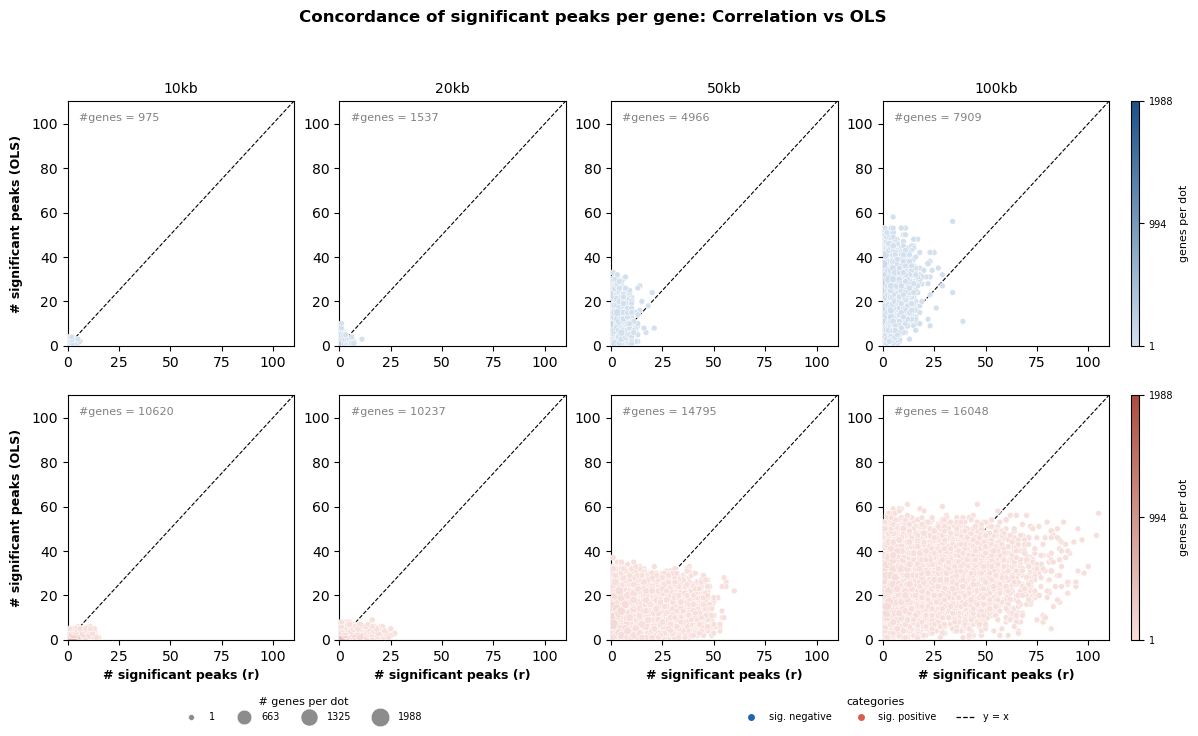

In [150]:
#plot the number of significant peaks per gene in correlation vs OLS results, colored by category and faceted by window & category
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

plot_df = agg_merged_df.dropna(subset=["count_cor", "count_ols", "window", "category", "gene"]).copy()
plot_df["window"] = pd.Categorical(
    plot_df["window"], categories=["10kb", "20kb", "50kb", "100kb"], ordered=True,
)
plot_df["category"] = pd.Categorical(
    plot_df["category"],
    categories=["sig. negative", "non-significant", "sig. positive"], ordered=True,
)

plot_sig_df = plot_df[plot_df["category"] != "non-significant"].copy()

# Count genes per (count_cor, count_ols, window, category) position
plot_sig_df["n_genes"] = plot_sig_df.groupby(
    ["window", "category", "count_cor", "count_ols"]
)["gene"].transform("count")

category_base_colors = {
    "sig. negative": "#2166ac",
    "sig. positive": "#d6604d",
}
category_order = ["sig. negative", "sig. positive"]
windows = ["10kb", "20kb", "50kb", "100kb"]

# Deduplicate to one row per unique (x, y, window, category) position
plot_dedup = plot_sig_df.drop_duplicates(
    subset=["count_cor", "count_ols", "window", "category"]
).copy()

# Global n_genes range for consistent size/color scaling
n_min = plot_dedup["n_genes"].min()
n_max = plot_dedup["n_genes"].max()

def make_alpha_cmap(hex_color):
    r, g, b = mcolors.to_rgb(hex_color)
    light = (1 - (1 - r) * 0.20, 1 - (1 - g) * 0.20, 1 - (1 - b) * 0.20)
    dark  = (r * 0.8, g * 0.8, b * 0.8)
    return mcolors.LinearSegmentedColormap.from_list("cat_cmap", [light, dark])
# ↑ removed hex_color midpoint — now light=n_min, dark=n_max, linear between them


def size_scale(n, n_min, n_max, s_min=18, s_max=180):
    """Map gene count to marker area (sqrt scaling feels more linear visually)."""
    if n_max == n_min:
        return (s_min + s_max) / 2
    return s_min + (s_max - s_min) * ((n - n_min) / (n_max - n_min)) ** 0.5

# plot: rows = categories, cols = windows, points colored by category 
fig, axes = plt.subplots(
    len(category_order), len(windows),
    figsize=(14, 7),
    sharex=False, sharey=False,
)

axis_max = plot_sig_df[["count_cor", "count_ols"]].max().max() * 1.05

for row_i, category in enumerate(category_order):
    cmap = make_alpha_cmap(category_base_colors[category])
    norm = Normalize(vmin=n_min, vmax=n_max) 
     # ✓ one colorbar per row, attached to the rightmost axis
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(
        sm,
        ax=axes[row_i, :],   # spans all axes in this row
        orientation="vertical",
        fraction=0.02,        # thin bar
        pad=0.02,
        aspect=30,
    )
    cbar.set_label("genes per dot", fontsize=8)
    cbar.ax.tick_params(labelsize=7)
    # tick at n_min, midpoint, n_max
    cbar.set_ticks([n_min, (n_min + n_max) // 2, n_max])

    for col_i, window in enumerate(windows):
        ax = axes[row_i, col_i]
        data = plot_dedup[
            (plot_dedup["window"] == window) &
            (plot_dedup["category"] == category)
        ]

        if not data.empty:
            sizes  = data["n_genes"].apply(lambda n: size_scale(n, n_min, n_max))
            colors = cmap(norm(data["n_genes"]))

            ax.scatter(
                data["count_cor"], data["count_ols"],
                s=sizes, c=colors,
                edgecolors="w", linewidths=0.4, zorder=3,
            )

        ax.plot([0, axis_max], [0, axis_max],
                color="k", linestyle="--", linewidth=0.8, zorder=0)
        ax.set_xlim(0, axis_max)
        ax.set_ylim(0, axis_max)

        if row_i == 0:
            ax.set_title(window, fontsize=10)
        if col_i == 0:
            ax.set_ylabel("# significant peaks (OLS)", fontsize=9, labelpad=6,fontweight="bold")
        else:
            ax.set_ylabel("")
        if row_i == len(category_order) - 1:
            ax.set_xlabel("# significant peaks (r)", fontsize=9,fontweight="bold")
        else:
            ax.set_xlabel("")

        n_total = data["n_genes"].sum()
        ax.text(0.05, 0.95, f"#genes = {n_total}", transform=ax.transAxes,
                ha="left", va="top", fontsize=8, color="0.5")

# ── Legend: size scale ────────────────────────────────────────────────────────
legend_counts = np.linspace(n_min, n_max, 4).astype(int)
size_handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markersize=np.sqrt(size_scale(n, n_min, n_max)),  # radius from area 
           markerfacecolor="0.55", markeredgecolor="w", markeredgewidth=0.4,
           label=str(n))
    for n in legend_counts
]
size_legend = fig.legend(
    size_handles,
    [str(n) for n in legend_counts],
    title=" # genes per dot",
    loc="lower left",
    bbox_to_anchor=(0.2, -0.02),
    ncol=len(legend_counts),
    frameon=False, fontsize=7,
    title_fontsize=8,
)

# ── Legend: diagonal line ─────────────────────────────────────────────────────
handles = [
    Line2D([0], [0], marker="o", linestyle="", 
           markerfacecolor=category_base_colors[c],
           markeredgecolor=category_base_colors[c],
           markersize=4, label=c)
    for c in category_order
]
handles.append(
    Line2D([0], [0], color="k", linestyle="--", linewidth=0.9, label="y = x")
)
fig.legend(
    handles=handles,
    title="categories",
    loc="lower left",
    bbox_to_anchor=(0.6, -0.02),
    frameon=False, fontsize= 7,
    ncol=len(handles),
    title_fontsize=8
)

plt.suptitle(
    "Concordance of significant peaks per gene: Correlation vs OLS",
    fontsize=12, y=1.01, fontweight="bold",
)

plt.show()



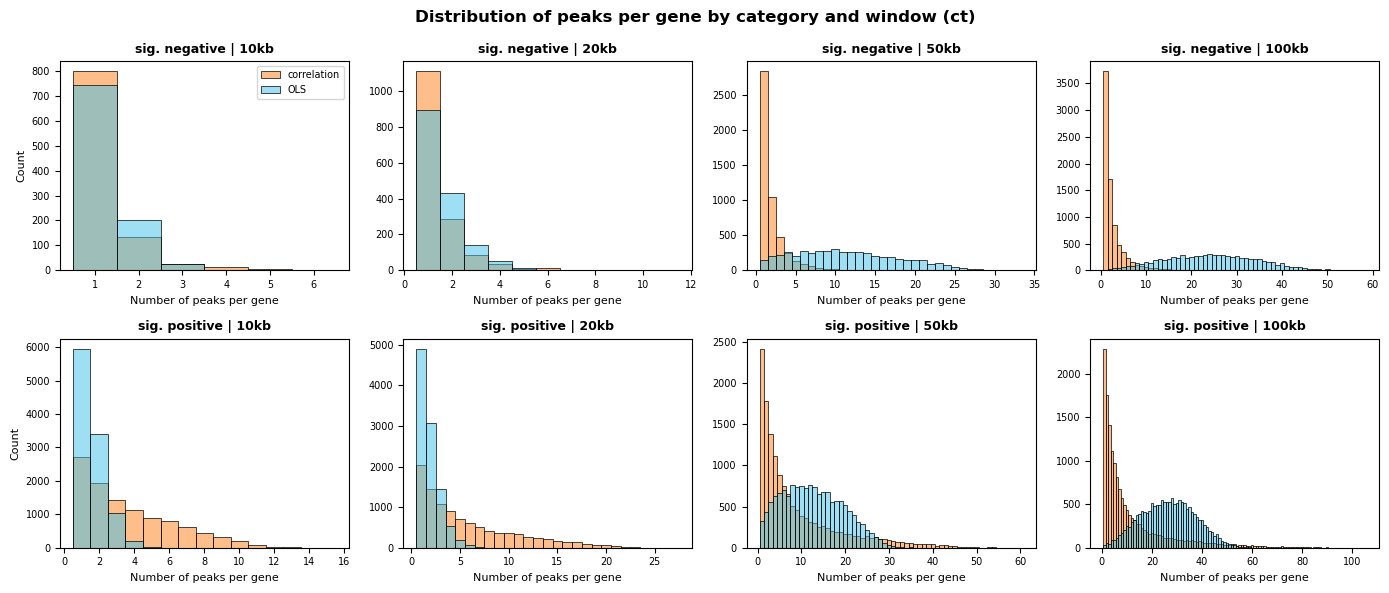

In [157]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = agg_merged_df.dropna(subset=["count_cor", "count_ols", "window", "category"]).copy()
plot_df["window"] = pd.Categorical(
    plot_df["window"],
    categories=["10kb", "20kb", "50kb", "100kb"],
    ordered=True,
)
plot_df["category"] = pd.Categorical(
    plot_df["category"],
    categories=["sig. negative", "non-significant", "sig. positive"],
    ordered=True,
)

plot_df_non = plot_df[plot_df["category"] != "non-significant"].copy()
plot_df_non["category"] = pd.Categorical(
    plot_df_non["category"],
    categories=["sig. negative", "sig. positive"],
    ordered=True,
)

window_labels = ["10kb", "20kb", "50kb", "100kb"]
category_order = ["sig. negative", "sig. positive"]
method_colors = {"correlation": "#fd7e16", "OLS": "#40c1e9"}

fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharex=False, sharey=False)

for row_idx, cat in enumerate(category_order):
    cat_data = plot_df_non[plot_df_non["category"] == cat]

    for col_idx, win in enumerate(window_labels):
        ax = axes[row_idx, col_idx]
        win_data = cat_data[cat_data["window"] == win]

        combined_counts = pd.concat([win_data["count_cor"], win_data["count_ols"]]).dropna()
        if combined_counts.empty:
            ax.set_axis_off()
            continue

        bin_edges = np.linspace(combined_counts.min(), combined_counts.max(), 16)
        if np.unique(bin_edges).size < 2:
            bin_edges = np.array([combined_counts.min() - 0.5, combined_counts.max() + 0.5])

        # Plot correlation histogram
        sns.histplot(
            win_data["count_cor"],
            bins=bin_edges,
            alpha=0.5,
            label="correlation",
            color=method_colors["correlation"],
            edgecolor="black",
            linewidth=0.5,
            discrete=True,
            ax = ax

        )
        # Plot OLS histogram
        sns.histplot(
            win_data["count_ols"],
            bins=bin_edges,
            alpha=0.5,
            label="OLS",
            color=method_colors["OLS"],
            edgecolor="black",
            linewidth=0.5,
            discrete=True,
            ax = ax
        )

        ax.set_xlabel("Number of peaks per gene", fontsize=8)
        ax.set_ylabel("Count" if col_idx == 0 else "", fontsize=8)
        ax.set_title(f"{cat} | {win}", fontsize=9, fontweight="bold")
        ax.tick_params(labelsize=7)

        if row_idx == 0 and col_idx == 0:
            ax.legend(loc="upper right", fontsize=7)

fig.suptitle("Distribution of peaks per gene by category and window (ct)", fontsize=12, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

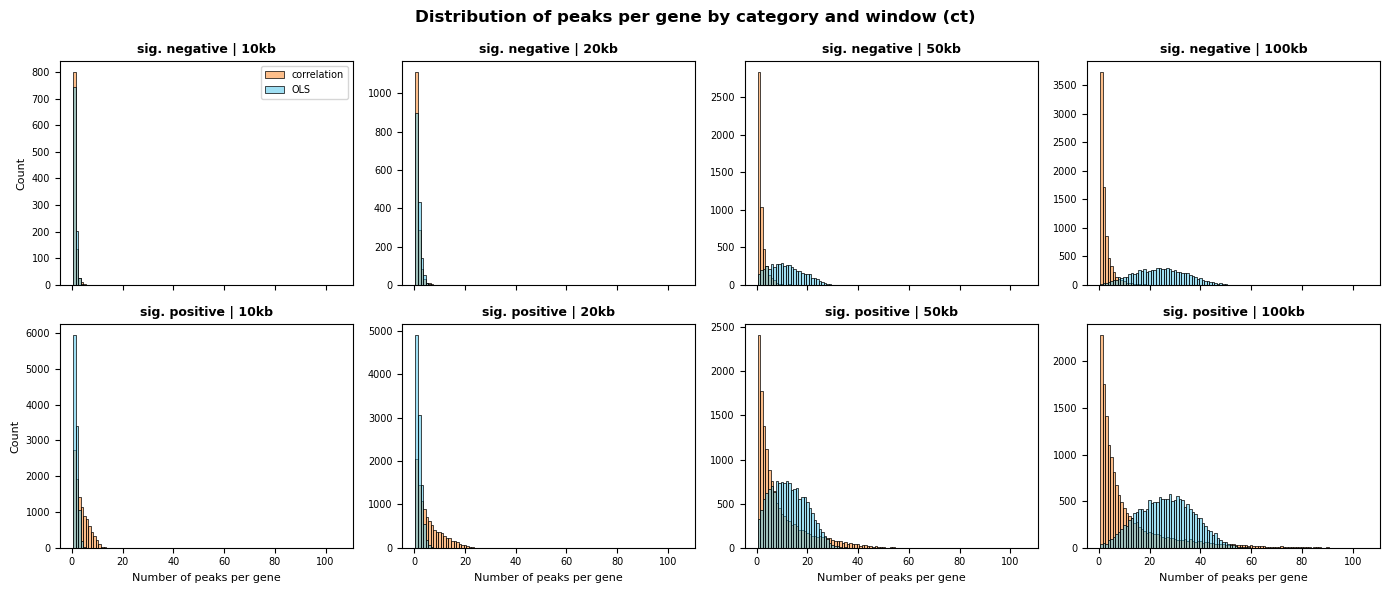

In [158]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = agg_merged_df.dropna(subset=["count_cor", "count_ols", "window", "category"]).copy()
plot_df["window"] = pd.Categorical(
    plot_df["window"],
    categories=["10kb", "20kb", "50kb", "100kb"],
    ordered=True,
)
plot_df["category"] = pd.Categorical(
    plot_df["category"],
    categories=["sig. negative", "non-significant", "sig. positive"],
    ordered=True,
)

plot_df_non = plot_df[plot_df["category"] != "non-significant"].copy()
plot_df_non["category"] = pd.Categorical(
    plot_df_non["category"],
    categories=["sig. negative", "sig. positive"],
    ordered=True,
)

window_labels = ["10kb", "20kb", "50kb", "100kb"]
category_order = ["sig. negative", "sig. positive"]
method_colors = {"correlation": "#fd7e16", "OLS": "#40c1e9"}

fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharex=True, sharey=False)

for row_idx, cat in enumerate(category_order):
    cat_data = plot_df_non[plot_df_non["category"] == cat]

    for col_idx, win in enumerate(window_labels):
        ax = axes[row_idx, col_idx]
        win_data = cat_data[cat_data["window"] == win]

        combined_counts = pd.concat([win_data["count_cor"], win_data["count_ols"]]).dropna()
        if combined_counts.empty:
            ax.set_axis_off()
            continue

        bin_edges = np.linspace(combined_counts.min(), combined_counts.max(), 16)
        if np.unique(bin_edges).size < 2:
            bin_edges = np.array([combined_counts.min() - 0.5, combined_counts.max() + 0.5])

        bin_width = max(1, (combined_counts.max() - combined_counts.min()) / 15)
      

        # Plot correlation histogram
        sns.histplot(
            win_data["count_cor"],
            bins=bin_edges,
            alpha=0.5,
            label="correlation",
            color=method_colors["correlation"],
            edgecolor="black",
            linewidth=0.5,
            discrete=True,
            ax = ax,
            binwidth=bin_width,

        )
        # Plot OLS histogram
        sns.histplot(
            win_data["count_ols"],
            bins=bin_edges,
            alpha=0.5,
            label="OLS",
            color=method_colors["OLS"],
            edgecolor="black",
            linewidth=0.5,
            discrete=True,
            ax = ax,
            binwidth=bin_width,
        )

        ax.set_xlabel("Number of peaks per gene", fontsize=8)
        ax.set_ylabel("Count" if col_idx == 0 else "", fontsize=8)
        ax.set_title(f"{cat} | {win}", fontsize=9, fontweight="bold")
        ax.tick_params(labelsize=7)

        if row_idx == 0 and col_idx == 0:
            ax.legend(loc="upper right", fontsize=7)

fig.suptitle("Distribution of peaks per gene by category and window (ct)", fontsize=12, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

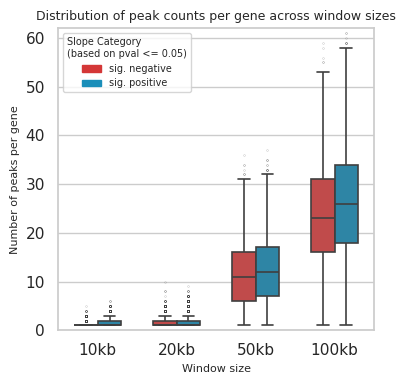

In [45]:
# Plot boxplot for each window colored by category (excluding non-significant)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd

window_labels = ["10kb", "20kb", "50kb", "100kb"]
category_order = ["sig. negative", "sig. positive"]
category_colors = {
    "sig. negative": "#D43737",
    "sig. positive": "#1A8EB9",
}

# Start from agg_ols_res_brief_df and remove non-significant category
plot_df = agg_ols_res_brief_df[agg_ols_res_brief_df["category"] != "non-significant"].copy()
plot_df = plot_df.dropna(subset=["count"])
plot_df["window"] = pd.Categorical(
    plot_df["window"],
    categories=window_labels,
    ordered=True,
)



fig, ax = plt.subplots(figsize=(4, 4))
sns.boxplot(
    data=plot_df,
    x="window",
    y="count",
    hue="category",
    hue_order=category_order,
    order=window_labels,
    palette=category_colors,
    width=0.6,
    linewidth=1.2,
    showfliers=True,
     flierprops={
        "marker": ".",
        "markersize": 2.5,
        "alpha": 0.5,
        "markeredgewidth": 0.2,
    },
    ax=ax,
 )

#scale the yaxis to the maximum outlier value across all windows
y_max = plot_df["count"].max()
ax.set_ylim(0, y_max + 1)
ax.set_xlabel("Window size", fontsize=8)
ax.set_ylabel("Number of peaks per gene", fontsize=8)
ax.set_title("Distribution of peak counts per gene across window sizes", fontsize=9)

legend_patches = [
    mpatches.Patch(color=category_colors[cat], label=cat)
    for cat in category_order
]
ax.legend(
    handles=legend_patches,
    title="Slope Category\n(based on pval <= 0.05)",
    fontsize=7,
    title_fontsize=7,
    frameon=True,
    loc="upper left",
)

plt.tight_layout()
plt.show()


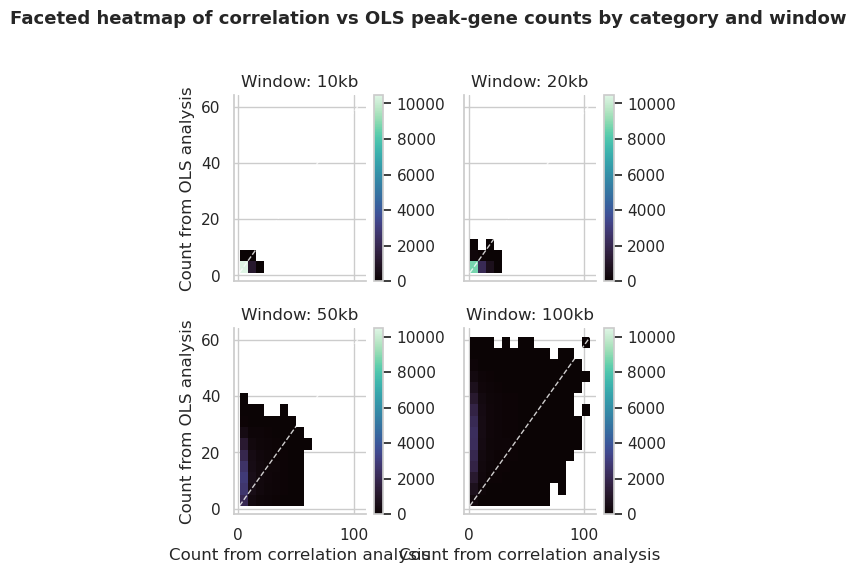

In [37]:
# Faceted 2D histogram heatmap of count_cor vs. count_ols by window and category
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_theme(style="whitegrid", context="notebook")

plot_df = agg_merged_df.dropna(subset=["count_cor", "count_ols", "window", "category"]).copy()
plot_df["window"] = pd.Categorical(
    plot_df["window"],
    categories=["10kb", "20kb", "50kb", "100kb"],
    ordered=True,
)
plot_df["category"] = pd.Categorical(
    plot_df["category"],
    categories=["sig. negative", "non-significant", "sig. positive"],
    ordered=True,
)

# Faceted heatmap-like plot using a 2D histogram
# columns = 2 rows
h = sns.displot(
    data=plot_df,
    x="count_cor",
    y="count_ols",
    col="window",
    col_wrap=2,
    col_order=["10kb", "20kb", "50kb", "100kb"],
    kind="hist",
    bins=15,
    cbar=True,
    cmap="mako",
    facet_kws={"sharex": True, "sharey": True},
    height=2.8,
    aspect=0.95,
)

x_min = plot_df["count_cor"].min()
x_max = plot_df["count_cor"].max()
y_min = plot_df["count_ols"].min()
y_max = plot_df["count_ols"].max()

for ax in h.axes.flat:
    ax.plot(
        [x_min, x_max],
        [y_min, y_max],
        linestyle="--",
        color="white",
        linewidth=1.0,
        alpha=0.8,
    )
    ax.set_xlabel("Count from correlation analysis")
    ax.set_ylabel("Count from OLS analysis")

h.set_titles(row_template="Category: {row_name}", col_template="Window: {col_name}")
h.figure.suptitle(
    "Faceted heatmap of correlation vs OLS peak-gene counts by category and window",
    y=1.02,
    fontsize=13,
    fontweight="bold",
)

plt.tight_layout()
plt.show()